In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel


# density_df = pd.read_csv("/Users/wuruoyu/Documents/Granger_MSThesis/data/analysis_results/results1/compiled/compiled_density_on_STRF_frobenius.csv")
density_df = pd.read_csv("/Users/wuruoyu/Documents/Granger_MSThesis/data/analysis_results/results1/compiled/compiled_density_on_STRF.csv")


In [2]:
density_df.head()


,date_id,monkey,condition,STRF_self_density,nSTRF_self_density,all_neurons_density
0,230420.0,Elay,A-hit,NaN,0.527778,0.527778
1,230420.0,Elay,A-miss,NaN,0.222222,0.222222
2,230420.0,Elay,AV-hit,NaN,0.583333,0.583333
3,230420.0,Elay,AV-miss,NaN,0.166667,0.166667
4,230509.0,Elay,A-hit,0.75,0.888889,0.880000


# monkeys & conditions

In [3]:
# array(['A-hit', 'A-miss', 'AV-hit', 'AV-miss'], dtype=object)
all_cond = list(pd.unique(density_df['condition'].dropna()))
all_cond

['A-hit', 'A-miss', 'AV-hit', 'AV-miss']

In [4]:
# array(['Elay', 'Wu'], dtype=object)
monkeys = list(pd.unique(density_df['monkey'].dropna()))
monkeys

['Elay', 'Wu']

In [ ]:
#['STRF_self_density', 'nSTRF_self_density', 'all_neurons_density']
all_groups = list(density_df.columns[-3:].to_numpy())

group_colors = {'STRF_self_density': 'red', 'nSTRF_self_density': 'blue', 'all_neurons_density': 'green'}


monkey_styles = {
    'Elay': '-',   # Solid line
    'Wu': '--'     # Dashed line
}


In [6]:
all_groups

['STRF_self_density', 'nSTRF_self_density', 'all_neurons_density']

In [7]:
wu = density_df.loc[density_df['monkey']=='Wu']
elay = density_df.loc[density_df['monkey']=='Elay']

# 1. cross Neuron Populations

## x Conditions

       STRF_self_density                     nSTRF_self_density            \
                   count      mean       std              count      mean   
monkey                                                                      
Elay                  68  0.590773  0.202544                 84  0.542272   
Wu                    76  0.711195  0.184514                 60  0.548218   

                 all_neurons_density                      
             std               count      mean       std  
monkey                                                    
Elay    0.252380                 144  0.525366  0.239643  
Wu      0.196741                 104  0.616478  0.187917  


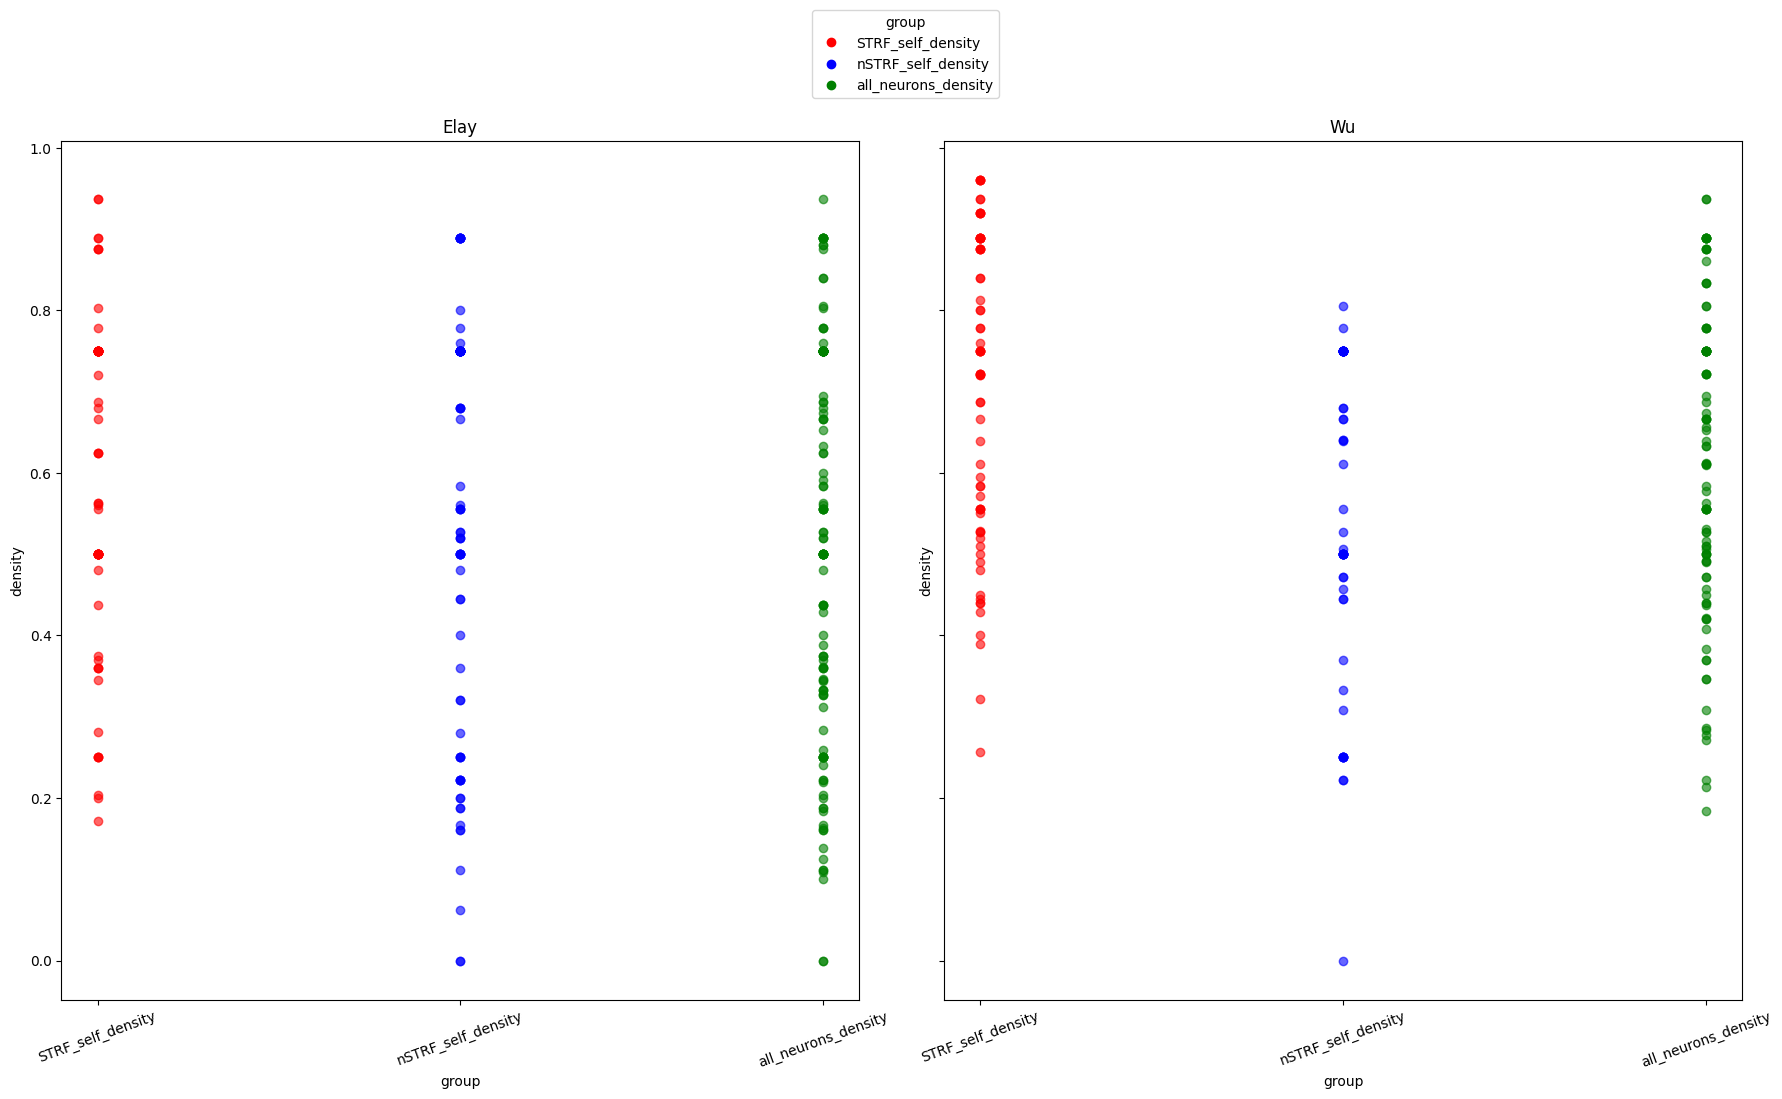

In [8]:

# per monkey / per group stats
stats = density_df.groupby('monkey')[all_groups].agg(['count', 'mean', 'std'])
print(stats)

# Plot each monkey separately with all groups in one scatter plot per monkey
fig, axes = plt.subplots(1, len(monkeys), figsize=(18, 10), sharey=True)
if len(monkeys) == 1:
    axes = [axes]

for ax, (monkey, group_df) in zip(axes, density_df.groupby('monkey')):
    x = np.arange(len(all_groups))
    for i, col in enumerate(all_groups):
        ax.scatter(np.full(len(group_df), x[i]), group_df[col], alpha=0.6, label=col, color=group_colors[col])
    ax.set_title(monkey)
    ax.set_xticks(x)
    ax.set_xticklabels(all_groups, rotation=20)
    ax.set_xlabel('group')
    ax.set_ylabel('density')
    

handles = [plt.Line2D([], [], marker='o', linestyle='', color=group_colors[col], label=col)
           for col in all_groups]
fig.legend(handles=handles, title='group', loc='center left', bbox_to_anchor=(0.45, 1.05))
fig.tight_layout()

## all levels

### scatter

                 STRF_self_density                     nSTRF_self_density  \
                             count      mean       std              count   
monkey condition                                                            
Elay   A-hit                    17  0.658242  0.209470                 21   
       A-miss                   17  0.524595  0.191272                 21   
       AV-hit                   17  0.677304  0.178873                 21   
       AV-miss                  17  0.502951  0.183549                 21   
Wu     A-hit                    19  0.716111  0.183535                 15   
       A-miss                   19  0.703603  0.190450                 15   
       AV-hit                   19  0.777629  0.140811                 15   
       AV-miss                  19  0.647435  0.207451                 15   

                                     all_neurons_density                      
                      mean       std               count      mean       

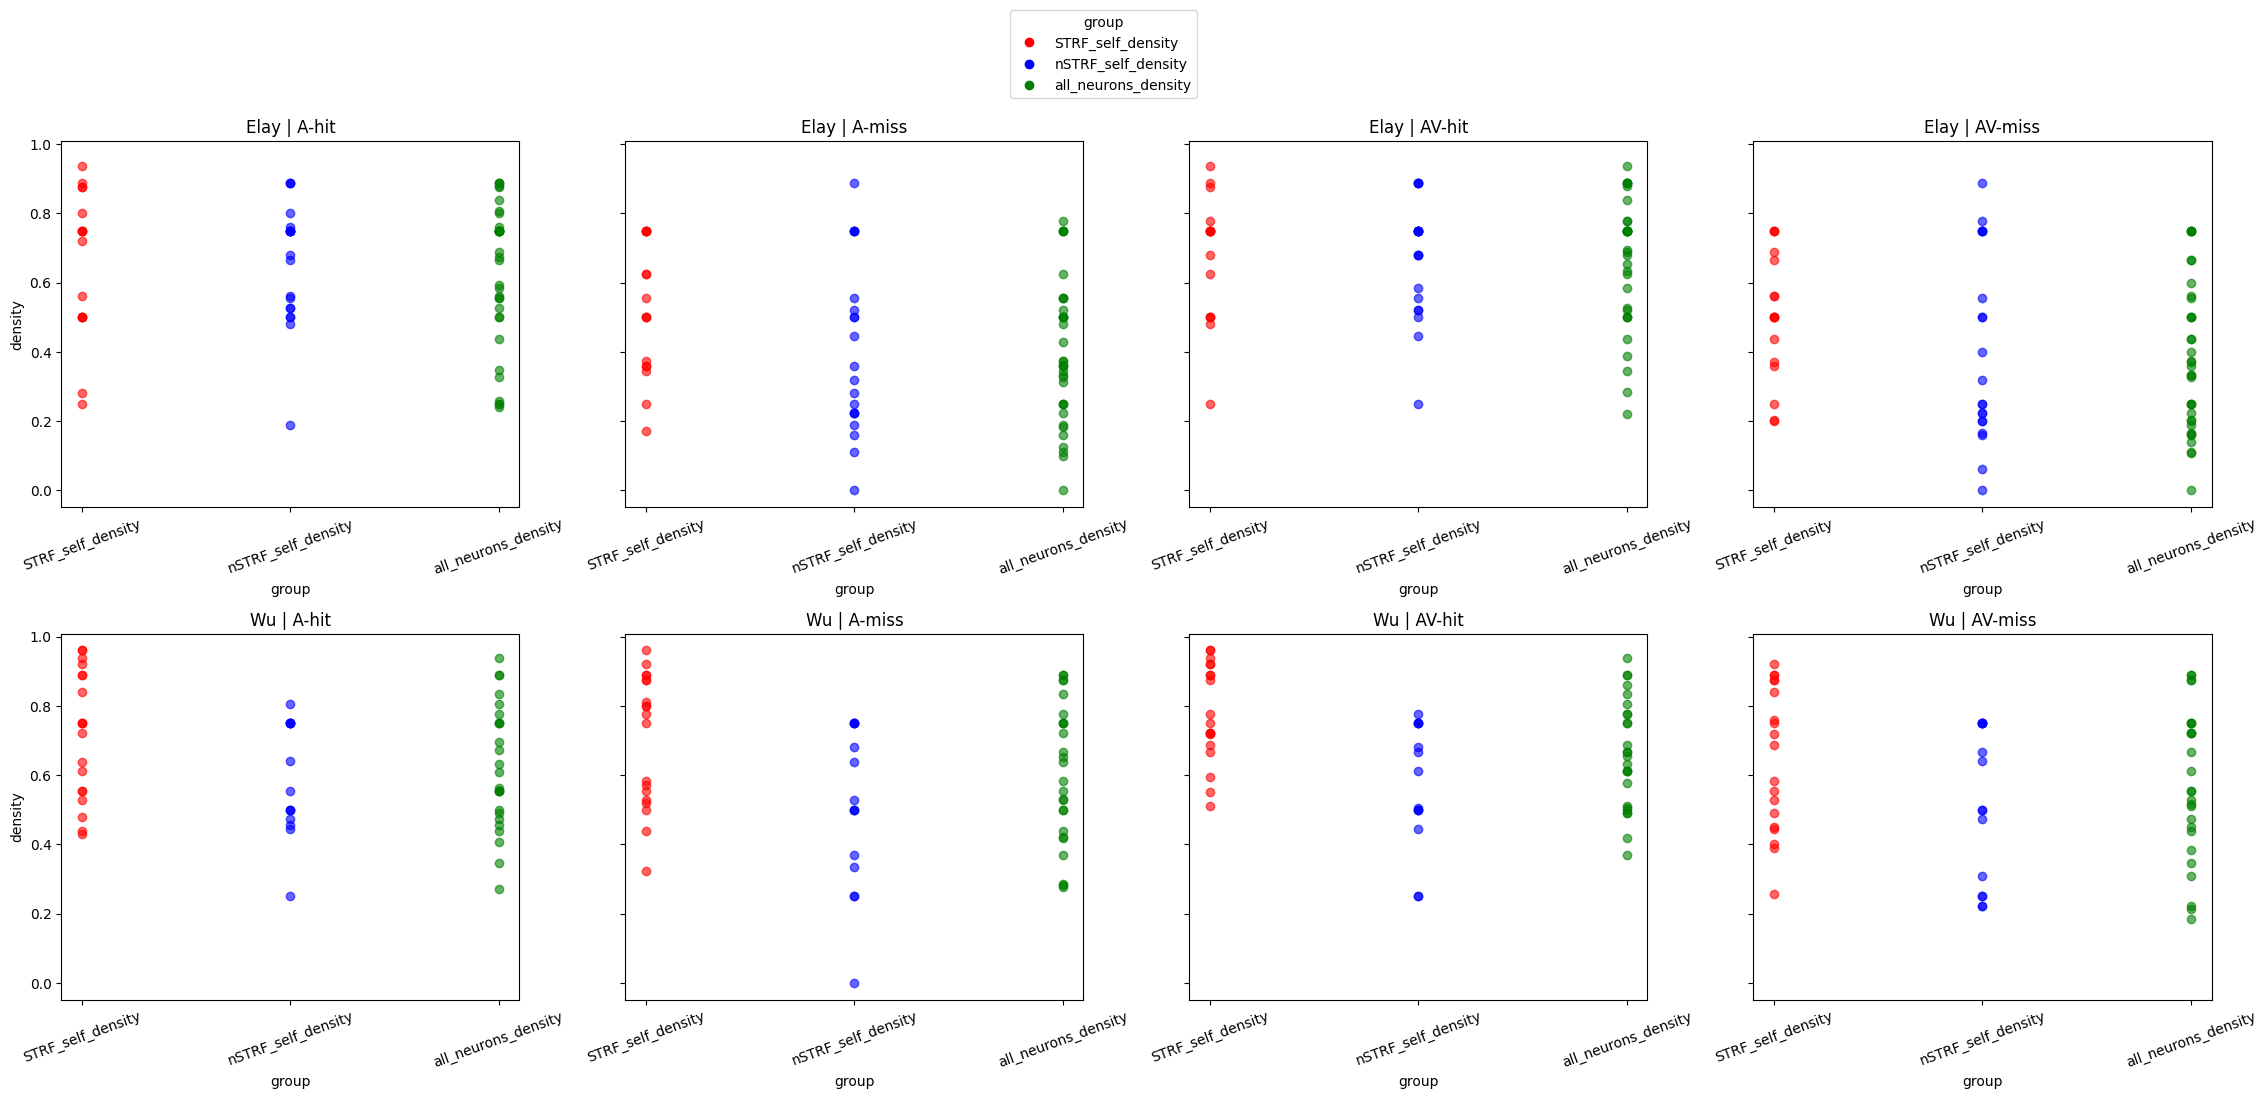

In [9]:
# per monkey / per condition / per group stats
stats_mc = density_df.groupby(['monkey', 'condition'])[all_groups].agg(['count', 'mean', 'std'])
print(stats_mc)

# Plot each monkey/condition separately with all groups in a separate scatter subplot
fig, axes = plt.subplots(len(monkeys), len(all_cond), figsize=(24, 10), sharey=True, squeeze=False)
for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes[i, j]
        subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
        x = np.arange(len(all_groups))
        for k, col in enumerate(all_groups):
            ax.scatter(np.full(len(subset), x[k]), subset[col], alpha=0.6, label=col, color=group_colors[col])
        ax.set_title(f"{monkey} | {cond}")
        ax.set_xticks(x)
        ax.set_xticklabels(all_groups, rotation=20)
        ax.set_xlabel('group')
        if j == 0:
            ax.set_ylabel('density')

# Shared legend outside the figure
handles = [plt.Line2D([], [], marker='o', linestyle='', color=group_colors[col], label=col)
           for col in all_groups]
fig.legend(handles=handles, title='group', loc='center left', bbox_to_anchor=(0.42, 1.05))
fig.tight_layout(rect=[0, 0, 0.95, 1])

### t-test

                 STRF_self_density                     nSTRF_self_density  \
                             count      mean       std              count   
monkey condition                                                            
Elay   A-hit                    17  0.658242  0.209470                 21   
       A-miss                   17  0.524595  0.191272                 21   
       AV-hit                   17  0.677304  0.178873                 21   
       AV-miss                  17  0.502951  0.183549                 21   
Wu     A-hit                    19  0.716111  0.183535                 15   
       A-miss                   19  0.703603  0.190450                 15   
       AV-hit                   19  0.777629  0.140811                 15   
       AV-miss                  19  0.647435  0.207451                 15   

                                     all_neurons_density                      
                      mean       std               count      mean       

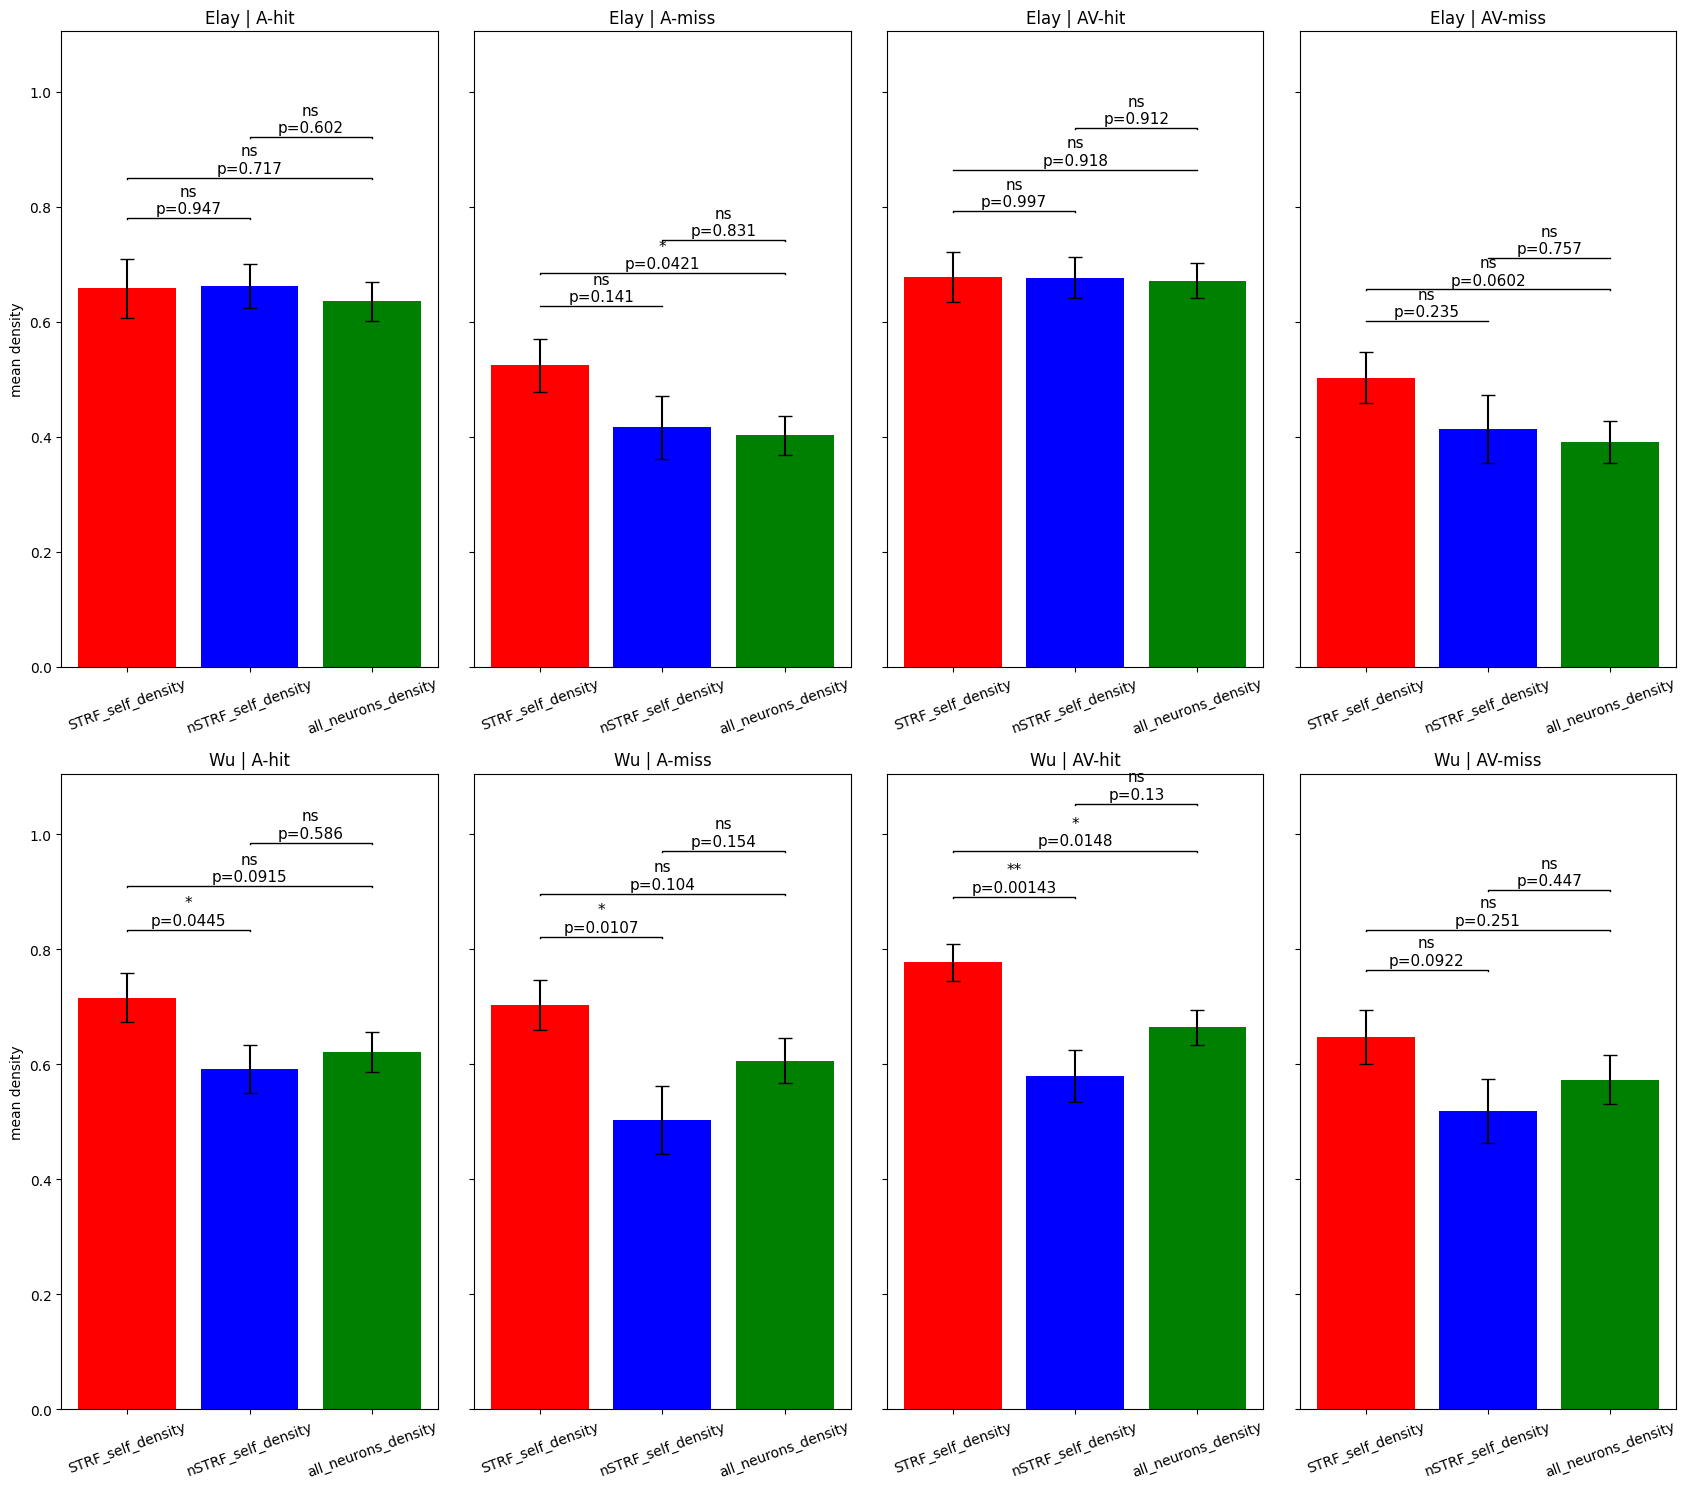

In [ ]:
from scipy.stats import ttest_ind

# per monkey / per condition / per group stats with t-tests
stats_mc = density_df.groupby(['monkey', 'condition'])[all_groups].agg(['count', 'mean', 'std'])
print(stats_mc)

fig, axes = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=True, squeeze=False)
#### define pairs for t-tests
pairs = [(0, 1), (0, 2), (1, 2)]
for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes[i, j]
        subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
        means = [subset[col].mean() for col in all_groups]
        sems = [subset[col].std(ddof=1) / np.sqrt(subset[col].count()) if subset[col].count() > 0 else np.nan
                for col in all_groups]

        x = np.arange(len(all_groups))
        ax.bar(x, means, yerr=sems, capsize=5, color=[group_colors[col] for col in all_groups])
        ax.set_xticks(x)
        ax.set_xticklabels(all_groups, rotation=20)
        ax.set_title(f"{monkey} | {cond}")
        if j == 0:
            ax.set_ylabel('mean density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base):
            y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        for k, (a, b) in enumerate(pairs):
            x1, x2 = x[a], x[b]
            data_a = subset[all_groups[a]].dropna()
            data_b = subset[all_groups[b]].dropna()
            if len(data_a) < 2 or len(data_b) < 2:
                pval = np.nan
                tstat = np.nan
                stars = 'n/a'
            else:
                tstat, pval = ttest_ind(data_a, data_b, equal_var=False)
                if pval < 0.001:
                    stars = '***'
                elif pval < 0.01:
                    stars = '**'
                elif pval < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

            y = y_base + (k + 1) * y_step
            ax.plot([x1, x1, x2, x2], [y - 0.02 * y_step, y, y, y - 0.02 * y_step], color='black', lw=1)
            ax.text((x1 + x2) / 2, y + 0.05 * y_step,
                    f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=11)
            print(f'{monkey} | {cond} | {all_groups[a]} vs {all_groups[b]}: t={tstat:.2f}, p={pval:.3g}, sig={stars}')

fig.tight_layout(rect=[0, 0, 0.95, 1])

# 2. by Neuron Populations

                 STRF_self_density                     nSTRF_self_density  \
                             count      mean       std              count   
monkey condition                                                            
Elay   A-hit                    17  0.658242  0.209470                 21   
       A-miss                   17  0.524595  0.191272                 21   
       AV-hit                   17  0.677304  0.178873                 21   
       AV-miss                  17  0.502951  0.183549                 21   
Wu     A-hit                    19  0.716111  0.183535                 15   
       A-miss                   19  0.703603  0.190450                 15   
       AV-hit                   19  0.777629  0.140811                 15   
       AV-miss                  19  0.647435  0.207451                 15   

                                     all_neurons_density                      
                      mean       std               count      mean       

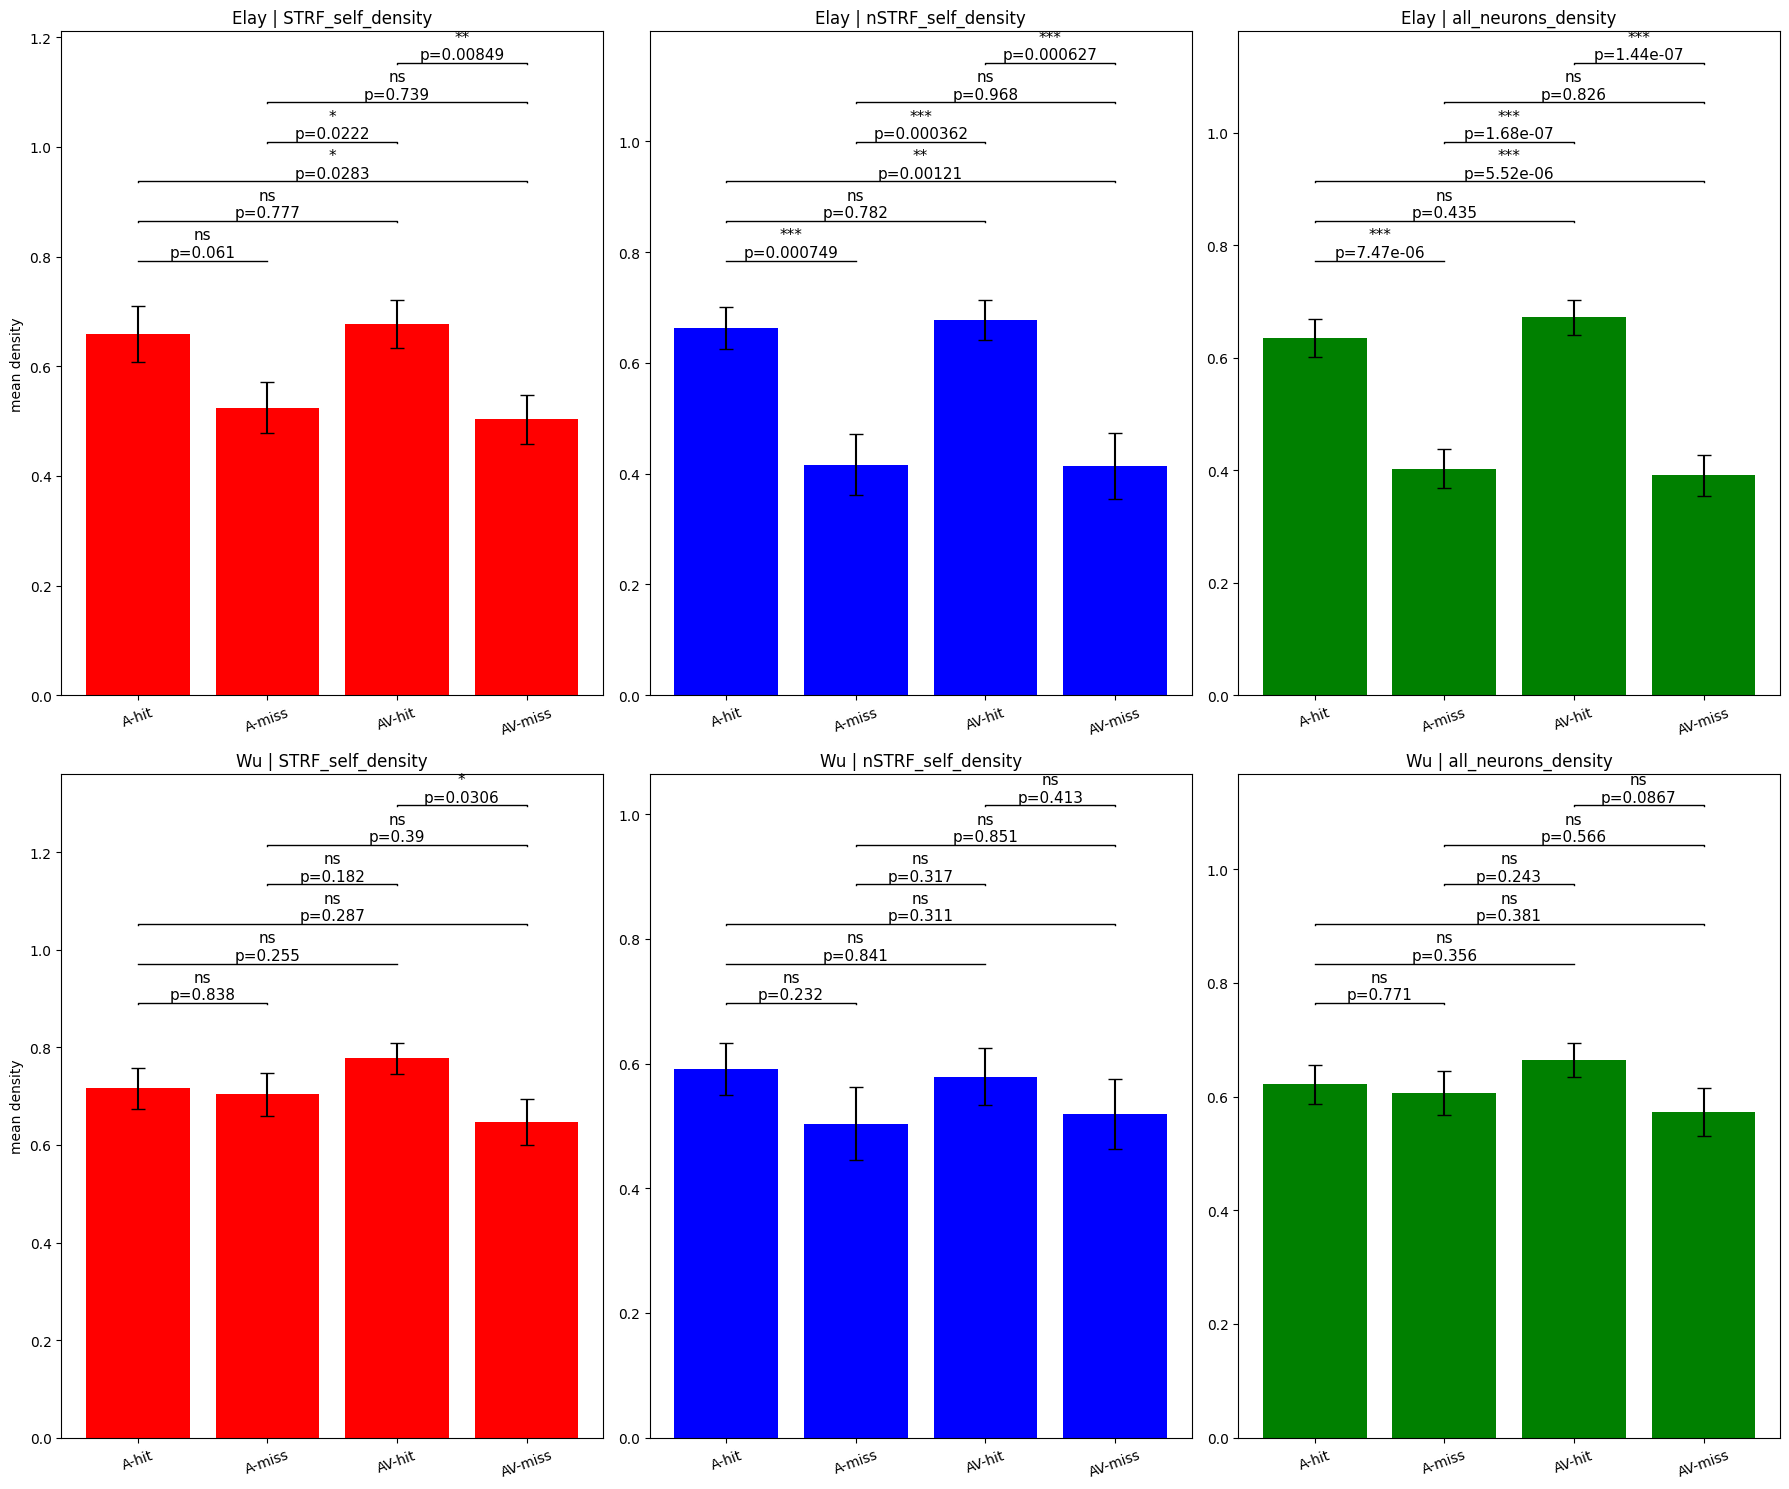

In [11]:
# per monkey / per group / across conditions stats with t-tests
stats_mg = density_df.groupby(['monkey', 'condition'])[all_groups].agg(['count', 'mean', 'std'])
print(stats_mg)

fig, axes = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)
cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes[i, j]
        means = []
        sems = []
        
        for cond in all_cond:
            subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
            mean = subset[group].mean()
            sem = subset[group].std(ddof=1) / np.sqrt(subset[group].count()) if subset[group].count() > 0 else np.nan
            means.append(mean)
            sems.append(sem)

        x = np.arange(len(all_cond))
        group_color = group_colors[group]
        ax.bar(x, means, yerr=sems, capsize=5, color=group_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}")
        if j == 0:
            ax.set_ylabel('mean density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base):
            y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        for k, (a, b) in enumerate(cond_pairs):
            if a >= len(all_cond) or b >= len(all_cond):
                continue
            x1, x2 = x[a], x[b]
            data_a = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == all_cond[a])][group].dropna()
            data_b = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == all_cond[b])][group].dropna()
            
            if len(data_a) < 2 or len(data_b) < 2:
                pval = np.nan
                tstat = np.nan
                stars = 'n/a'
            else:
                tstat, pval = ttest_ind(data_a, data_b, equal_var=False)
                if pval < 0.001:
                    stars = '***'
                elif pval < 0.01:
                    stars = '**'
                elif pval < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

            y = y_base + (k + 1) * y_step
            ax.plot([x1, x1, x2, x2], [y - 0.015 * y_step, y, y, y - 0.02 * y_step], color='black', lw=1)
            ax.text((x1 + x2) / 2, y + 0.02 * y_step,
                    f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=11)
            print(f'{monkey} | {group} | {all_cond[a]} vs {all_cond[b]}: t={tstat:.2f}, p={pval:.3g}, sig={stars}')

fig.tight_layout(rect=[0, 0, 1, 1])

# 3. overtime

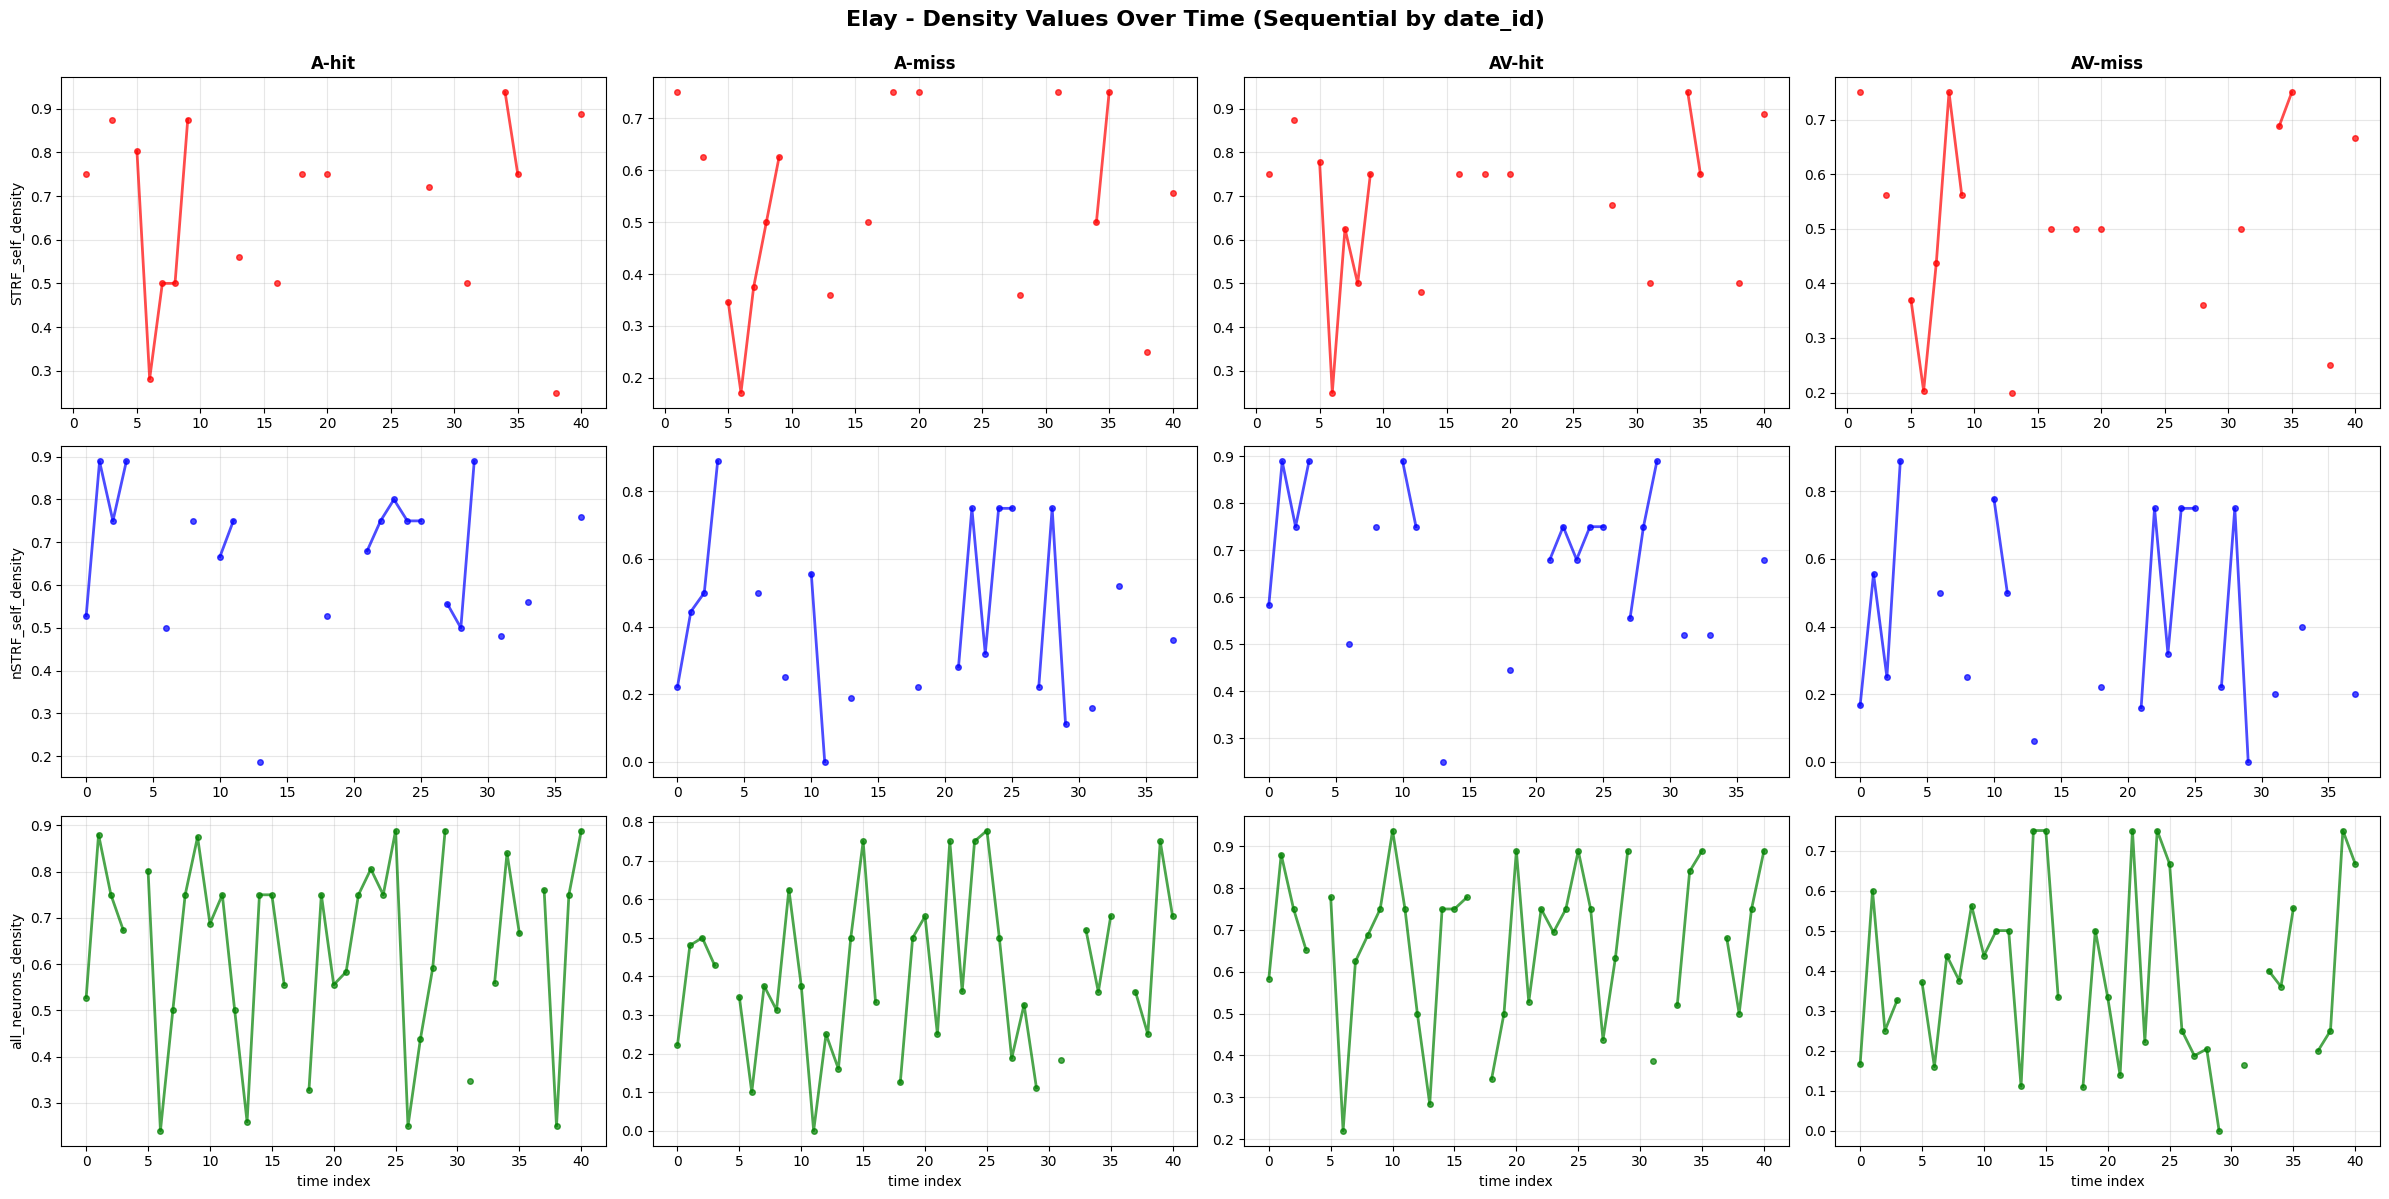

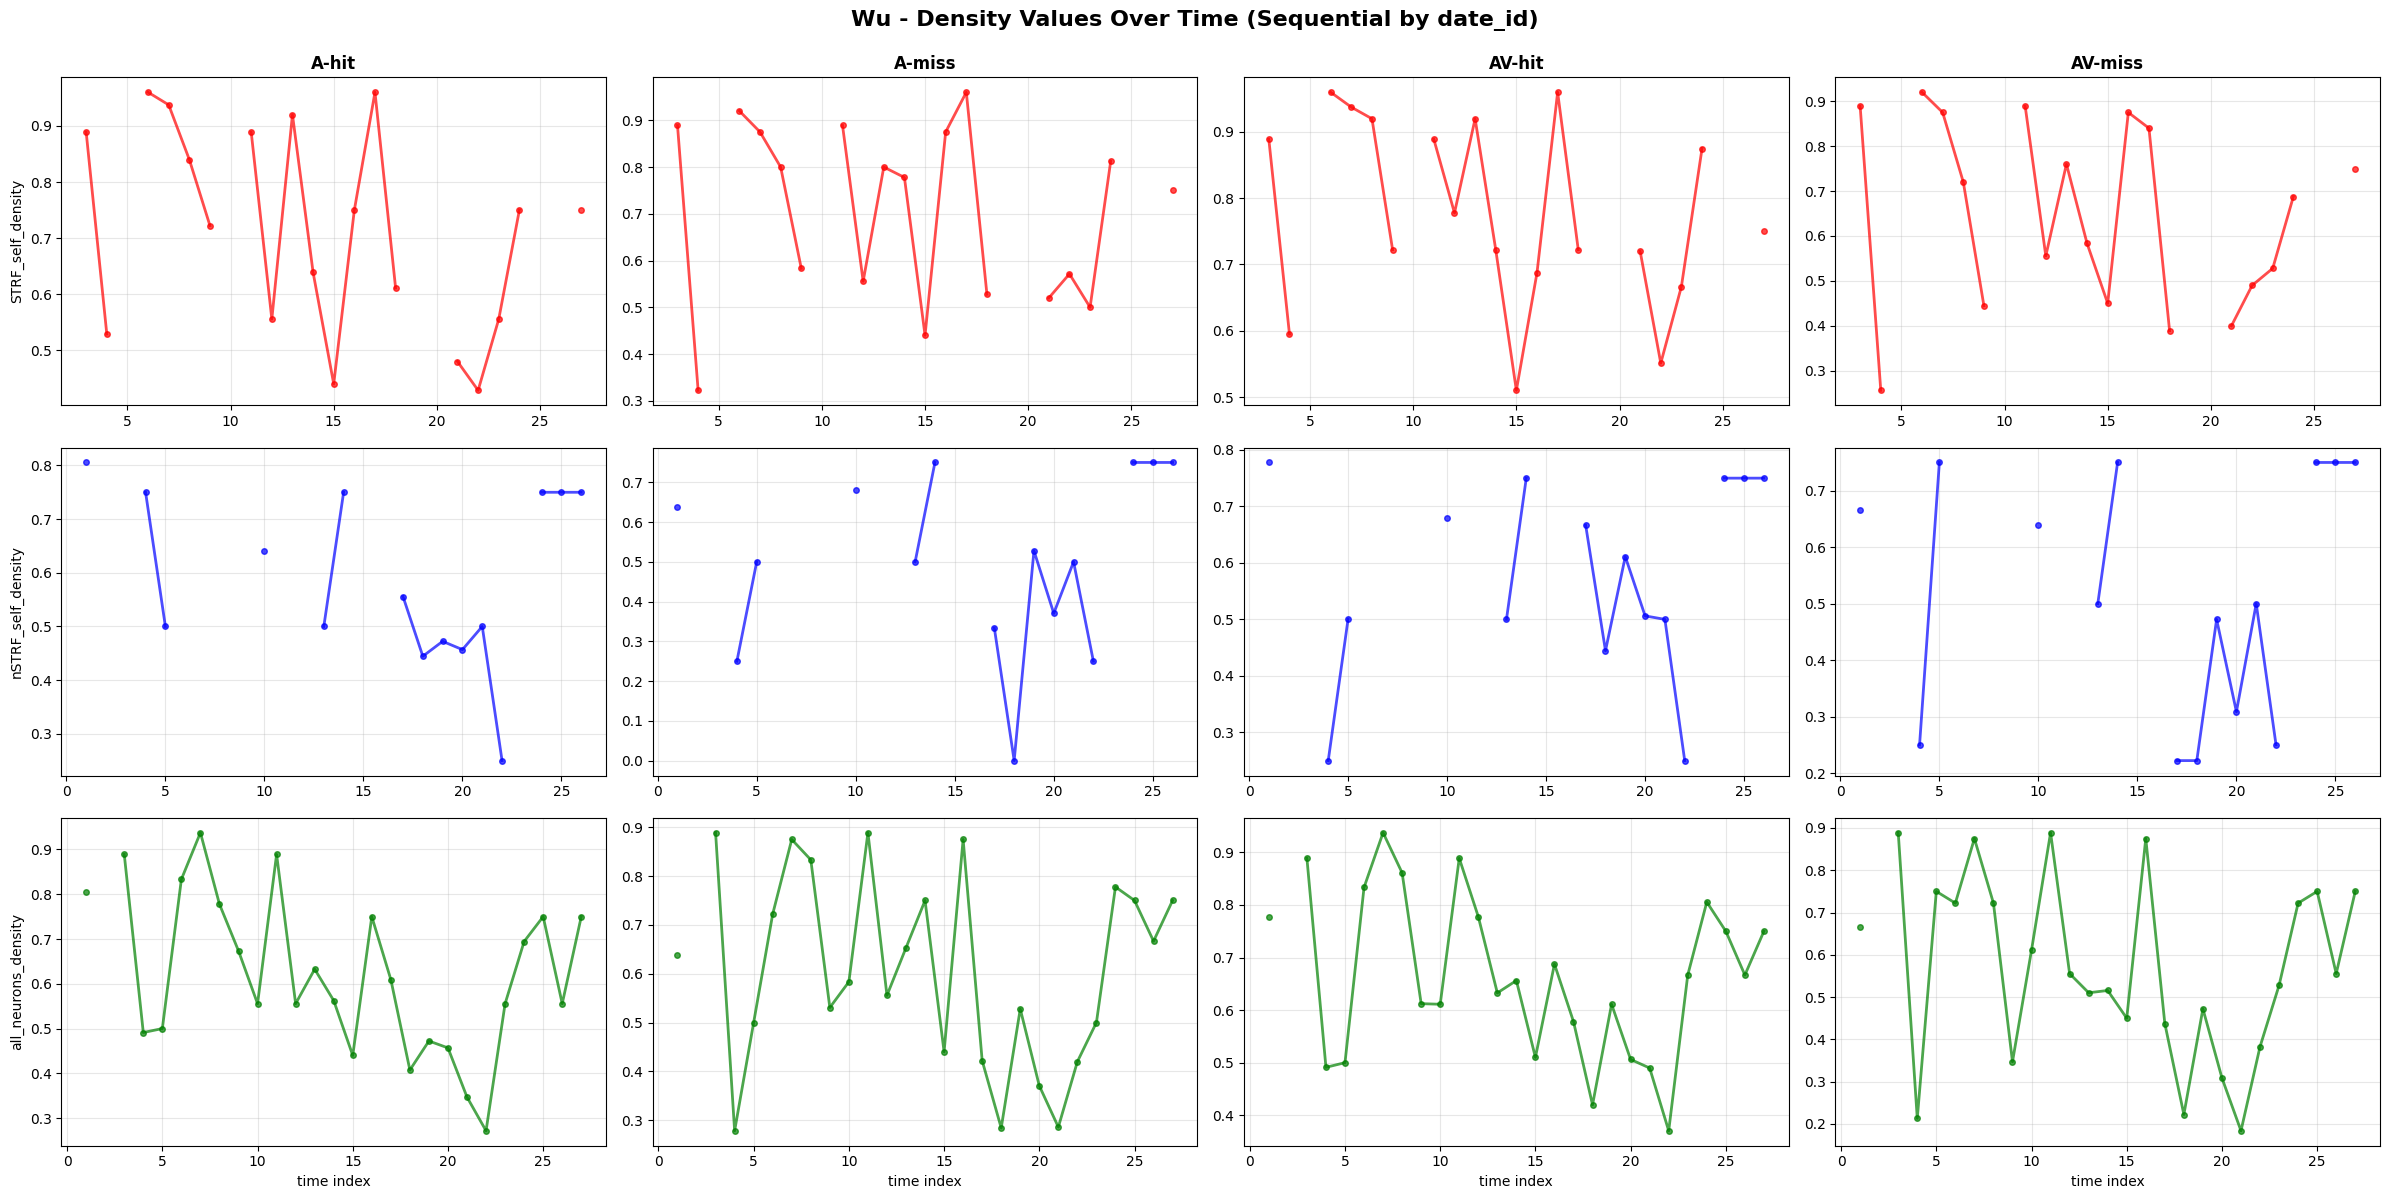

In [12]:
# Plot density values over time (date_id) for each monkey, condition, and group
# Create separate plots for each monkey
for monkey in monkeys:
    fig, axes = plt.subplots(len(all_groups), len(all_cond), figsize=(24, 12), sharey=False, squeeze=False)
    
    for j, group in enumerate(all_groups):
        for k, cond in enumerate(all_cond):
            ax = axes[j, k]
            
            # Filter data for this monkey, condition, and group
            subset = density_df[(density_df['monkey'] == monkey) & (density_df['condition'] == cond)]
            
            # Sort by date_id to ensure chronological order
            subset = subset.sort_values('date_id')
            
            # Create x-axis as sequential indices (treating date_id as IDs, not uniformly spaced dates)
            x = np.arange(len(subset))
            
            # Plot the line for this group
            ax.plot(x, subset[group].values, marker='o', linestyle='-', 
                   label=group, color=group_colors[group], linewidth=2, markersize=4, alpha=0.7)
            
            # Set labels and title
            if j == 0:
                ax.set_title(f"{cond}", fontsize=12, fontweight='bold')
            if k == 0:
                ax.set_ylabel(f"{group}", fontsize=10)
            if j == len(all_groups) - 1:
                ax.set_xlabel('time index', fontsize=10)
            
            ax.grid(True, alpha=0.3)
            
    
    fig.suptitle(f'{monkey} - Density Values Over Time (Sequential by date_id)', fontsize=16, fontweight='bold', y=0.995)
    fig.tight_layout()
    plt.show()

# 4. simple density vs frobenius density

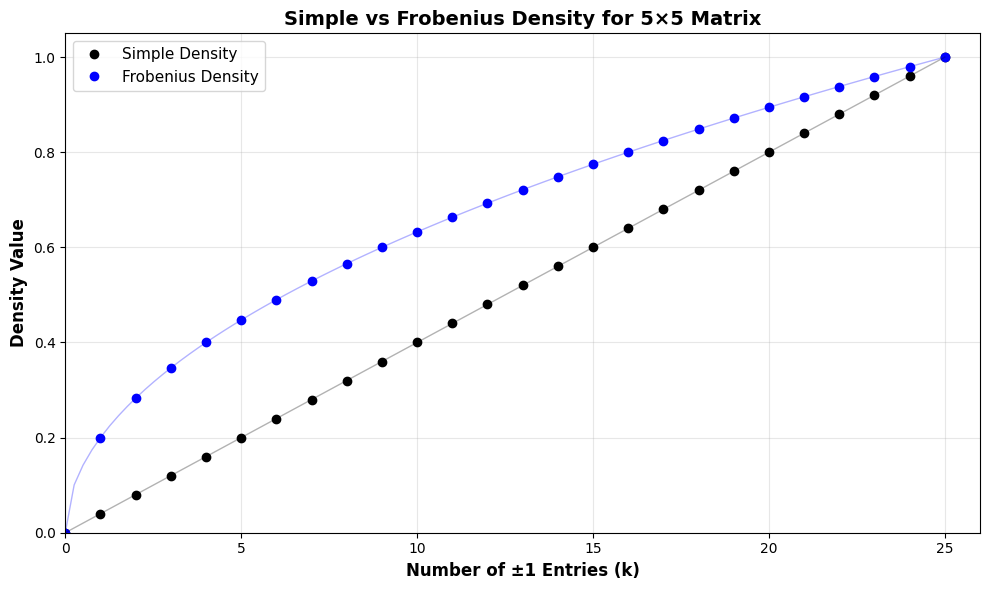

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix size
n = 5
total_entries = n * n  # 25 entries

# Define range of non-zero entries (0 to 25)
num_entries = np.arange(0, total_entries + 1)

# Pre-allocate arrays for densities
simple_density = np.zeros(len(num_entries))
frobenius_density_corrected = np.zeros(len(num_entries))

# Calculate densities for each number of entries
for i, k in enumerate(num_entries):
    # Create a matrix with k entries set to either 1 or -1
    mat = np.zeros((n, n))
    if k > 0:
        mat_flat = mat.flatten()
        for j in range(k):
            mat_flat[j] = 1 if j % 2 == 0 else -1
        mat = mat_flat.reshape((n, n))
    
    # Calculate Simple Density (mean absolute value)
    simple_density[i] = np.sum(np.abs(mat)) / total_entries
    
    # Corrected Frobenius Density
    frobenius_norm = np.linalg.norm(mat, 'fro')
    max_possible_norm = np.sqrt(total_entries)
    frobenius_density_corrected[i] = frobenius_norm / max_possible_norm

# Create single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with black dots for simple density, blue dots for frobenius density
ax.plot(num_entries, simple_density, 'k.', markersize=12, label='Simple Density')
ax.plot(num_entries, frobenius_density_corrected, 'b.', markersize=12, label='Frobenius Density')

# Add theoretical curves
k_theoretical = np.linspace(0, total_entries, 100)
simple_theoretical = k_theoretical / total_entries
frobenius_theoretical = np.sqrt(k_theoretical) / np.sqrt(total_entries)

ax.plot(k_theoretical, simple_theoretical, 'k-', alpha=0.3, linewidth=1)
ax.plot(k_theoretical, frobenius_theoretical, 'b-', alpha=0.3, linewidth=1)

# Customize plot
ax.set_xlabel('Number of ±1 Entries (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density Value', fontsize=12, fontweight='bold')
ax.set_title(f'Simple vs Frobenius Density for {n}×{n} Matrix', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, total_entries + 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# 5. paired t-test

### two-sided

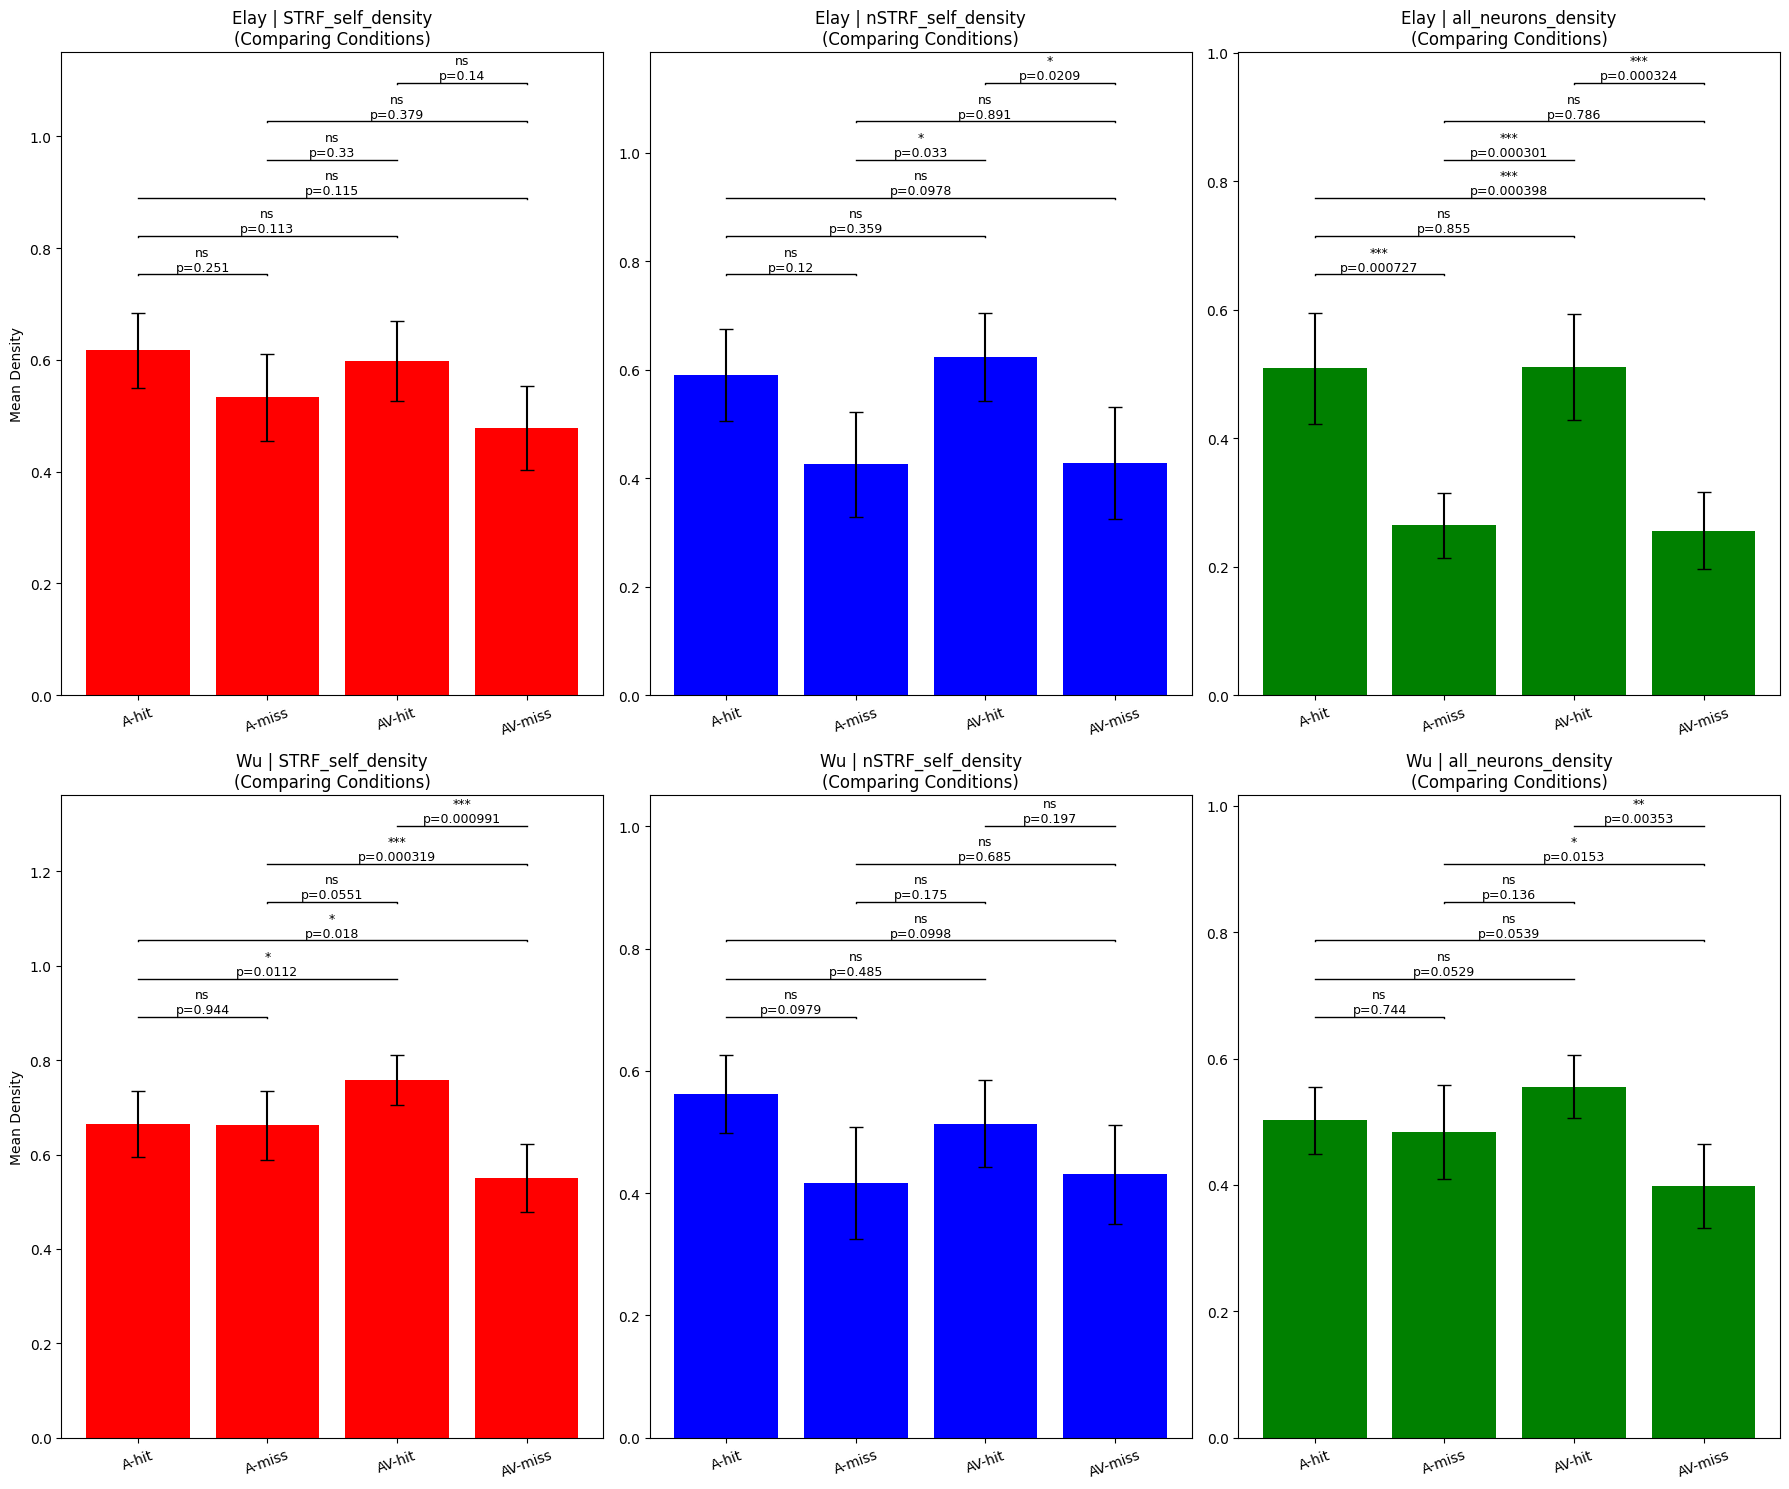

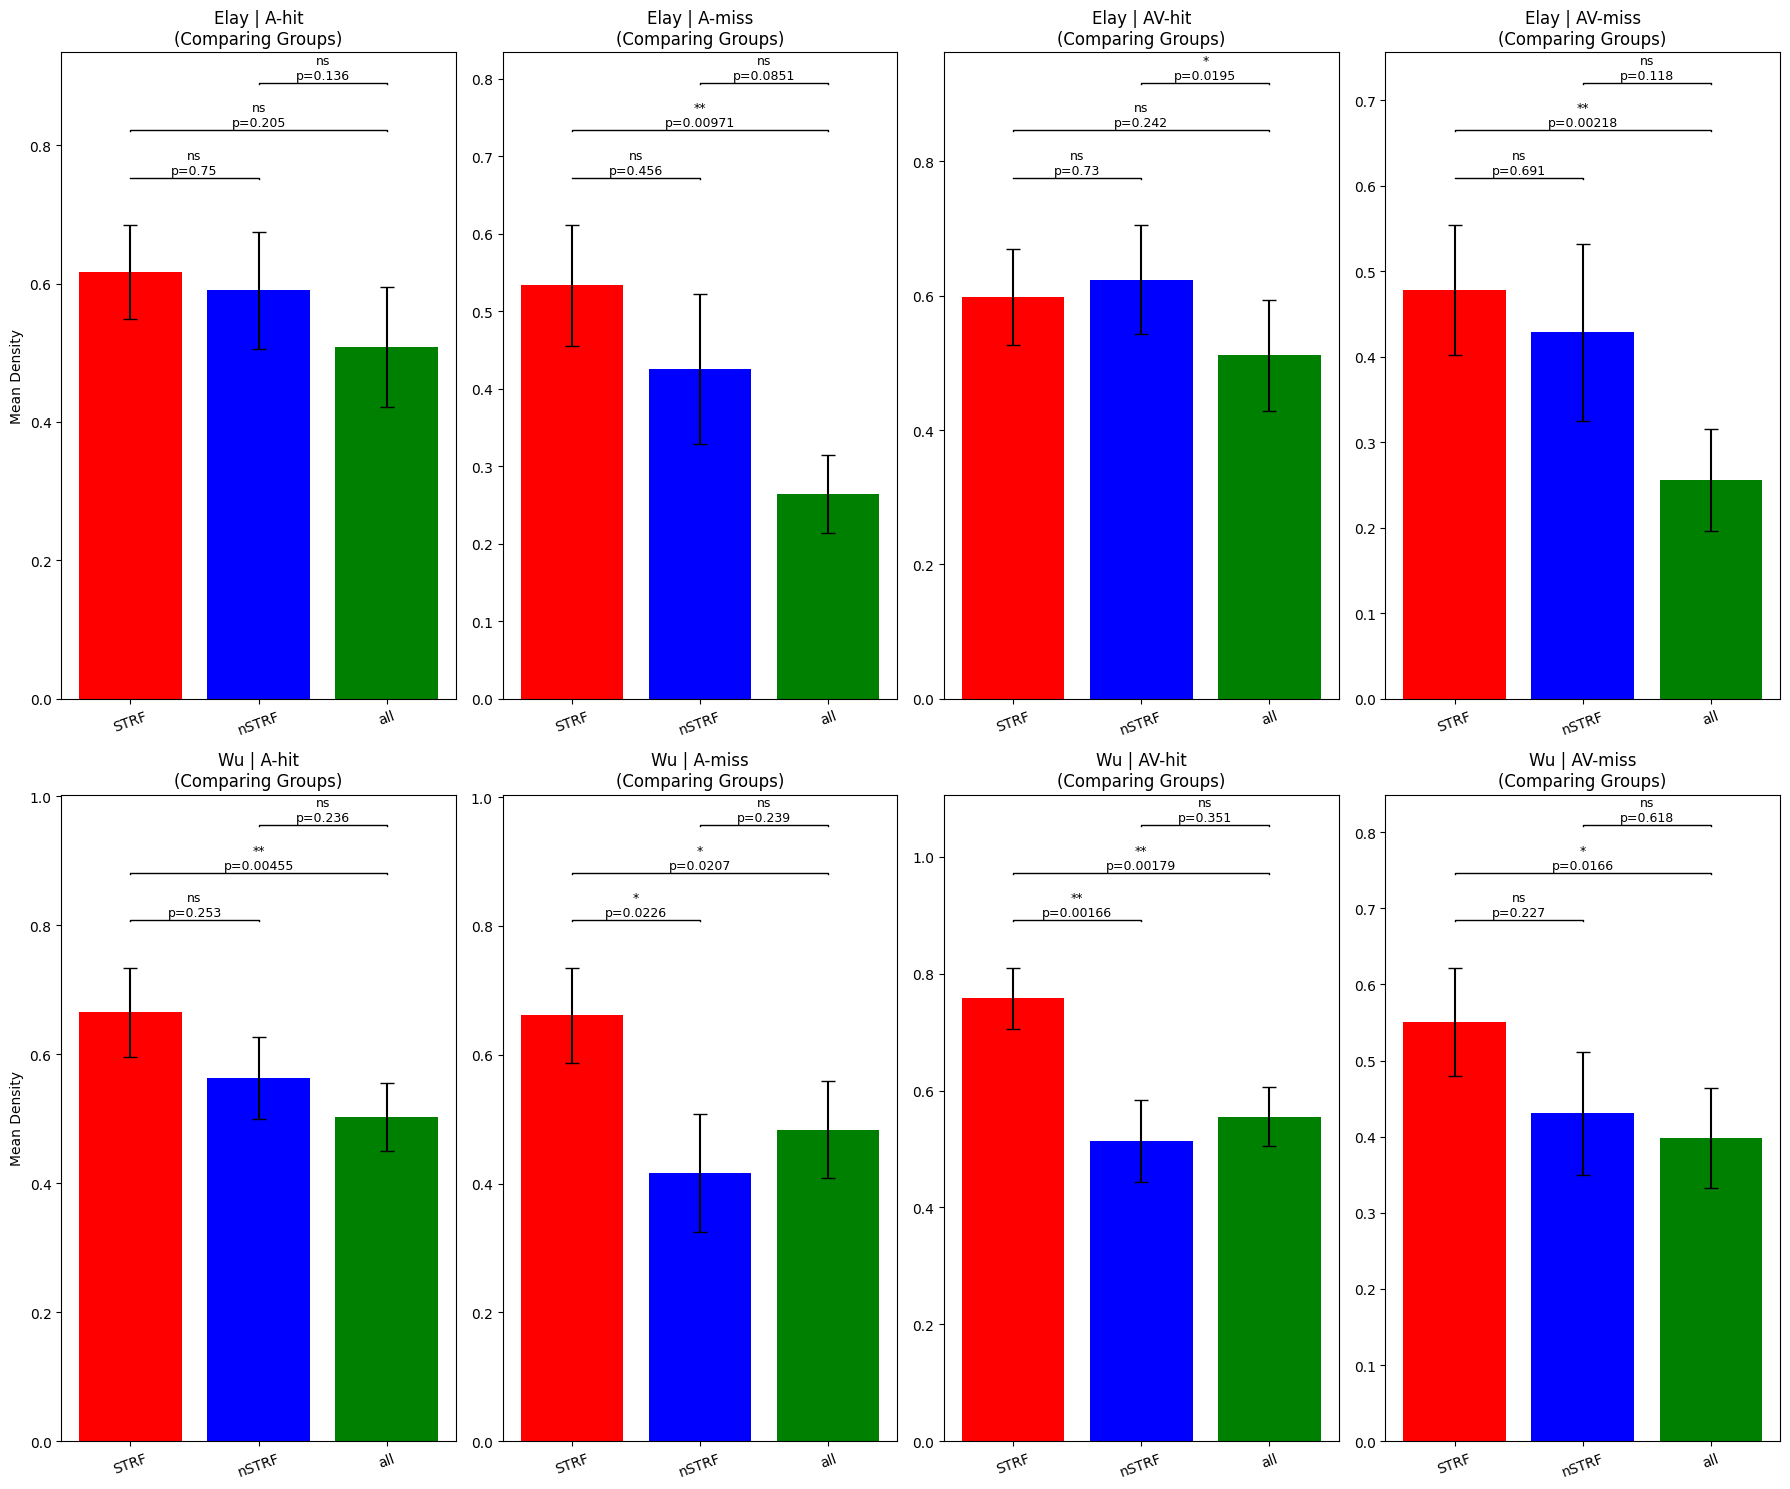

In [ ]:


# Predefined color rule
# group_colors = {'STRF_self_density': 'red', 'nSTRF_self_density': 'blue', 'all_neurons_density': 'green'}

# Ensure data is clean
density_df_clean = density_df.dropna(subset=all_groups + ['monkey', 'condition'])

results_paired_ttest_byconditions = {}

fig1, axes1 = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes1[i, j]
        means = []
        sems = []
        
        cond_data = {}
        for cond in all_cond:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            cond_data[cond] = vals
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_cond))
        bar_color = group_colors.get(group, 'skyblue')
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}\n(Comparing Conditions)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
        
        for k, (a_idx, b_idx) in enumerate(cond_pairs):
            cond_a = all_cond[a_idx]
            cond_b = all_cond[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_a)][['date_id', group]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_b)][['date_id', group]]
            
            # Rename columns to ensure unique suffixes after merge
            df_a = df_a.rename(columns={group: f'{group}_a'})
            df_b = df_b.rename(columns={group: f'{group}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    #actual test here
                    tstat, pval = ttest_rel(merged[f'{group}_a'], merged[f'{group}_b'])
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{group}|{cond_a}_vs_{cond_b}"
            results_paired_ttest_byconditions[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

results_paired_ttest_bygroups = {}

fig2, axes2 = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes2[i, j]
        means = []
        sems = []
        
        group_data = {}
        for group in all_groups:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            group_data[group] = vals
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_groups))
        # Apply predefined colors for each group bar
        bar_colors = [group_colors.get(g, 'gray') for g in all_groups]
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('_self_density', '').replace('_neurons_density', '') for g in all_groups], rotation=20)
        ax.set_title(f"{monkey} | {cond}\n(Comparing Groups)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        group_indices = list(range(len(all_groups)))
        group_pairs = [(0, 1), (0, 2), (1, 2)]
        
        for k, (a_idx, b_idx) in enumerate(group_pairs):
            grp_a = all_groups[a_idx]
            grp_b = all_groups[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_a]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_b]]
            
            # Rename columns to ensure unique suffixes after merge
            df_a = df_a.rename(columns={grp_a: f'{grp_a}_a'})
            df_b = df_b.rename(columns={grp_b: f'{grp_b}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    tstat, pval = ttest_rel(merged[f'{grp_a}_a'], merged[f'{grp_b}_b'])
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{cond}|{grp_a}_vs_{grp_b}"
            results_paired_ttest_bygroups[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### one-sided


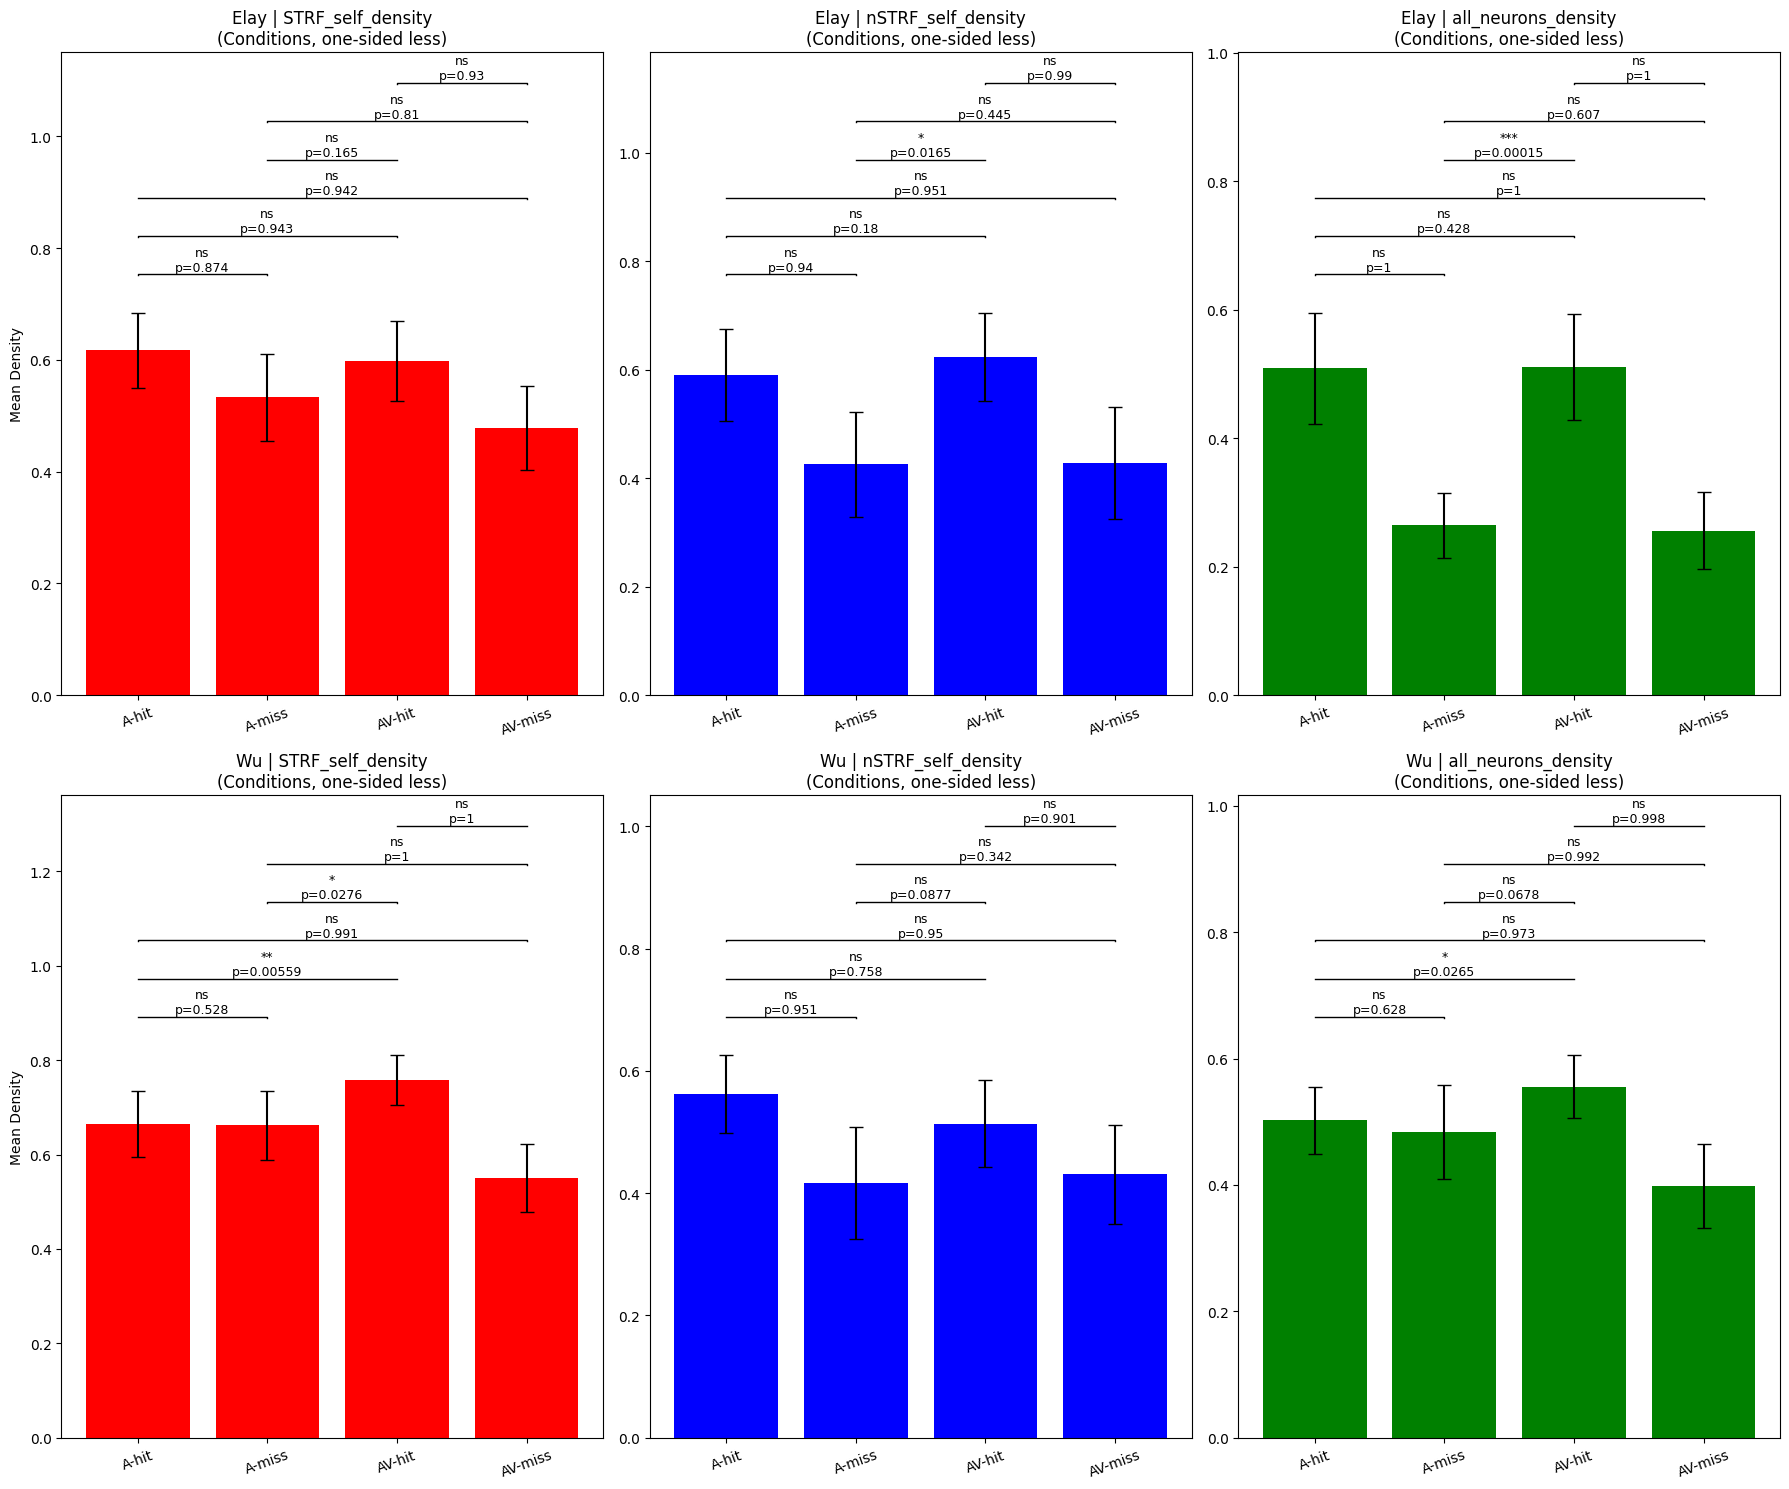

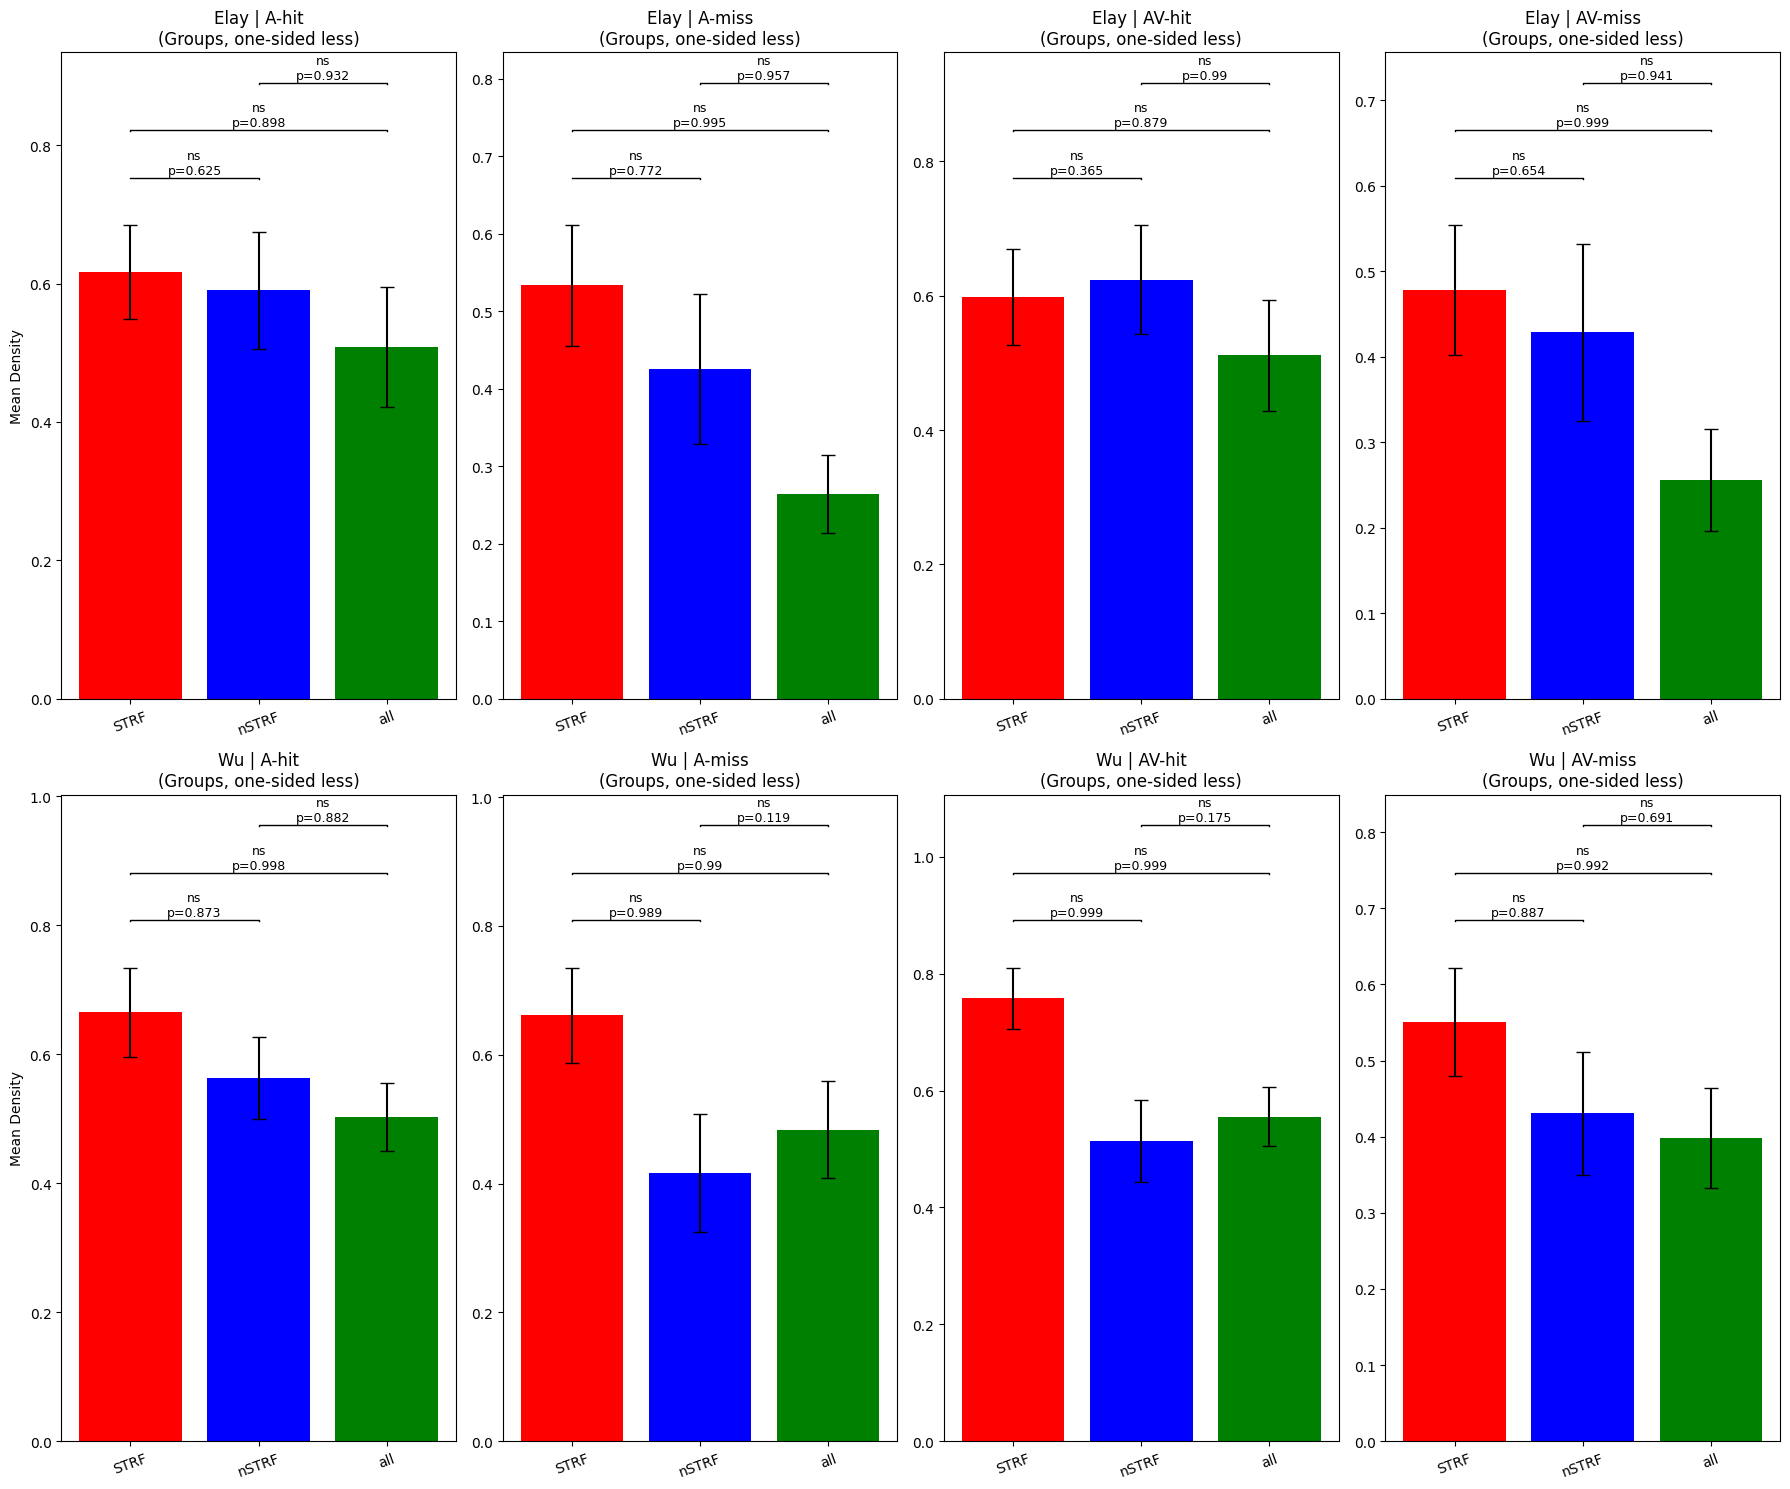

In [30]:
results_paired_ttest_byconditions_less = {}

fig_cond_less, axes_cond_less = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes_cond_less[i, j]
        means = []
        sems = []
        
        cond_data = {}
        for cond in all_cond:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            cond_data[cond] = vals
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_cond))
        bar_color = group_colors.get(group, 'skyblue')
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}\n(Conditions, one-sided less)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
        
        for k, (a_idx, b_idx) in enumerate(cond_pairs):
            cond_a = all_cond[a_idx]
            cond_b = all_cond[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_a)][['date_id', group]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_b)][['date_id', group]]
            
            df_a = df_a.rename(columns={group: f'{group}_a'})
            df_b = df_b.rename(columns={group: f'{group}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    tstat, pval = ttest_rel(merged[f'{group}_a'], merged[f'{group}_b'], alternative='less')
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{group}|{cond_a}_vs_{cond_b}"
            results_paired_ttest_byconditions_less[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

results_paired_ttest_bygroups_less = {}

fig_grp_less, axes_grp_less = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes_grp_less[i, j]
        means = []
        sems = []
        
        for group in all_groups:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_groups))
        bar_colors = [group_colors.get(g, 'gray') for g in all_groups]
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('_self_density', '').replace('_neurons_density', '') for g in all_groups], rotation=20)
        ax.set_title(f"{monkey} | {cond}\n(Groups, one-sided less)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        group_pairs = [(0, 1), (0, 2), (1, 2)]
        
        for k, (a_idx, b_idx) in enumerate(group_pairs):
            grp_a = all_groups[a_idx]
            grp_b = all_groups[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_a]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_b]]
            
            df_a = df_a.rename(columns={grp_a: f'{grp_a}_a'})
            df_b = df_b.rename(columns={grp_b: f'{grp_b}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    tstat, pval = ttest_rel(merged[f'{grp_a}_a'], merged[f'{grp_b}_b'], alternative='less')
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{cond}|{grp_a}_vs_{grp_b}"
            results_paired_ttest_bygroups_less[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

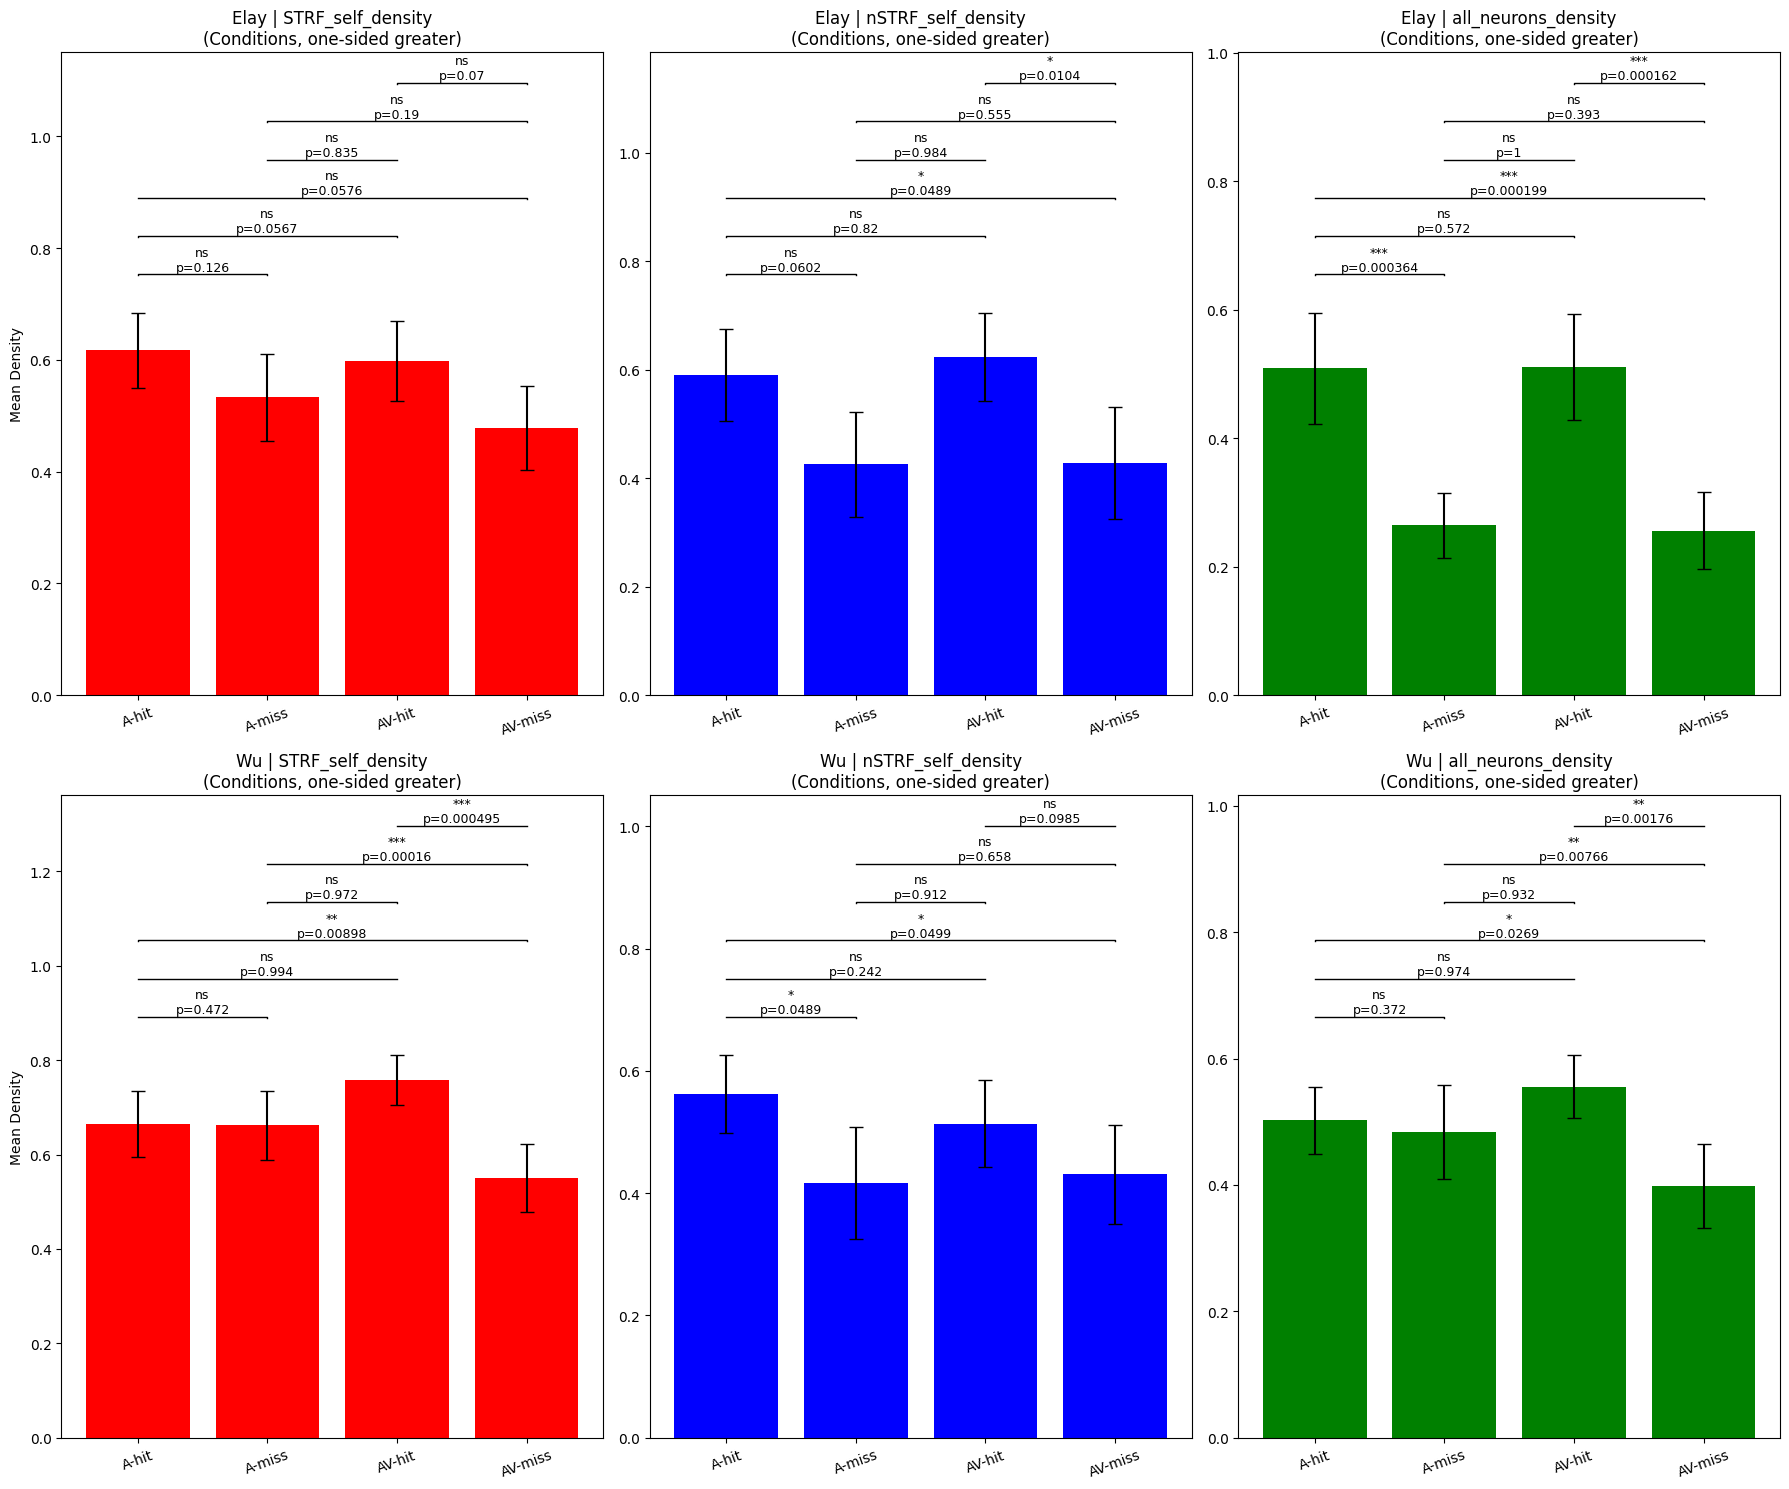

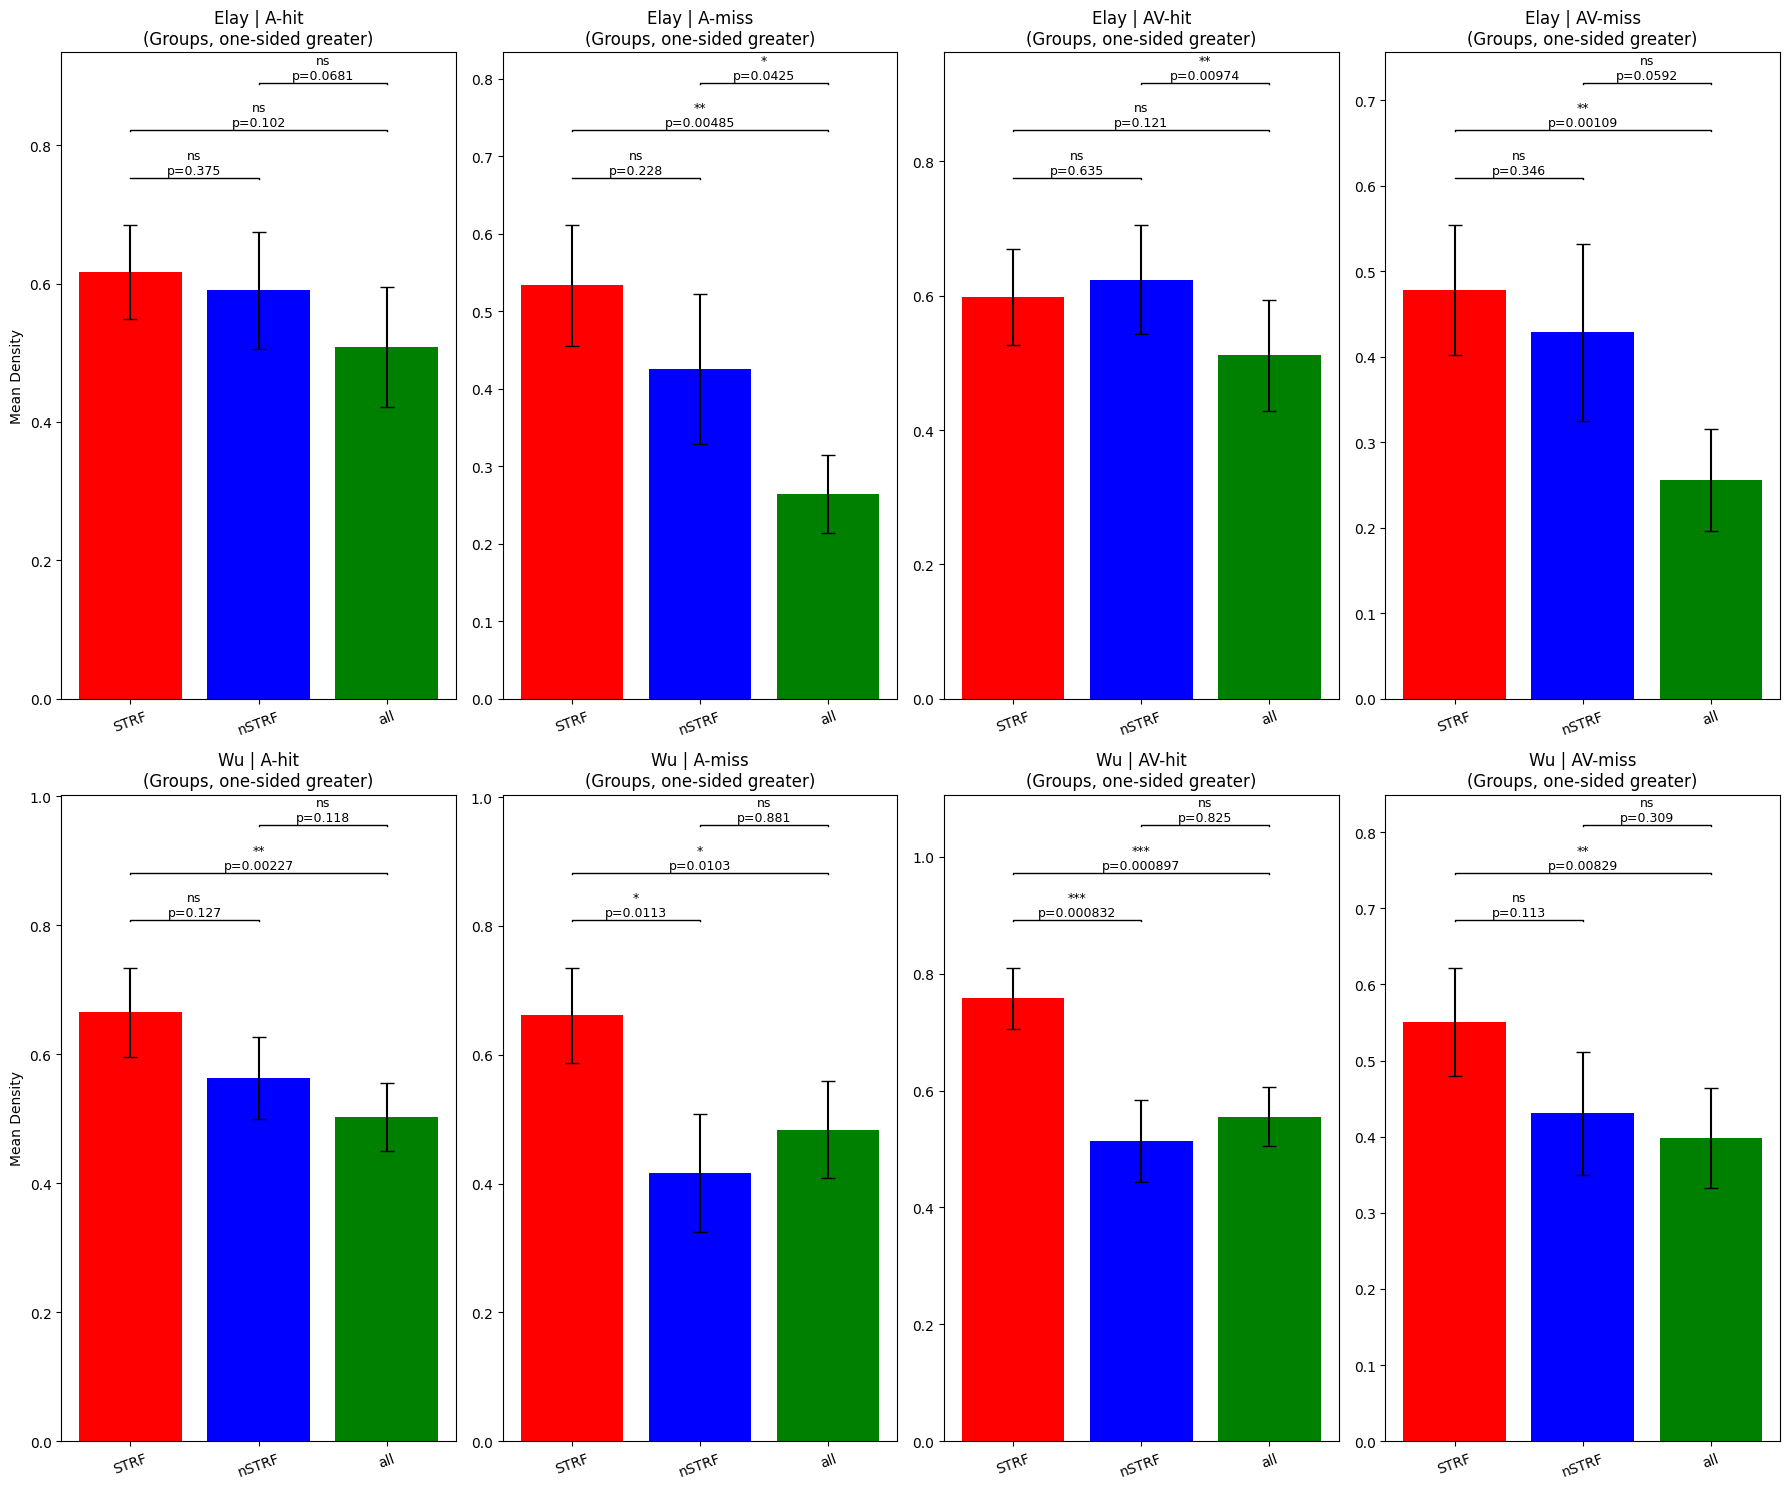

In [31]:
results_paired_ttest_byconditions_greater = {}

fig_cond_greater, axes_cond_greater = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes_cond_greater[i, j]
        means = []
        sems = []
        
        cond_data = {}
        for cond in all_cond:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            cond_data[cond] = vals
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_cond))
        bar_color = group_colors.get(group, 'skyblue')
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}\n(Conditions, one-sided greater)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
        
        for k, (a_idx, b_idx) in enumerate(cond_pairs):
            cond_a = all_cond[a_idx]
            cond_b = all_cond[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_a)][['date_id', group]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_b)][['date_id', group]]
            
            df_a = df_a.rename(columns={group: f'{group}_a'})
            df_b = df_b.rename(columns={group: f'{group}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    tstat, pval = ttest_rel(merged[f'{group}_a'], merged[f'{group}_b'], alternative='greater')
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{group}|{cond_a}_vs_{cond_b}"
            results_paired_ttest_byconditions_greater[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

results_paired_ttest_bygroups_greater = {}

fig_grp_greater, axes_grp_greater = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes_grp_greater[i, j]
        means = []
        sems = []
        
        for group in all_groups:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_groups))
        bar_colors = [group_colors.get(g, 'gray') for g in all_groups]
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('_self_density', '').replace('_neurons_density', '') for g in all_groups], rotation=20)
        ax.set_title(f"{monkey} | {cond}\n(Groups, one-sided greater)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        group_pairs = [(0, 1), (0, 2), (1, 2)]
        
        for k, (a_idx, b_idx) in enumerate(group_pairs):
            grp_a = all_groups[a_idx]
            grp_b = all_groups[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_a]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_b]]
            
            df_a = df_a.rename(columns={grp_a: f'{grp_a}_a'})
            df_b = df_b.rename(columns={grp_b: f'{grp_b}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    tstat, pval = ttest_rel(merged[f'{grp_a}_a'], merged[f'{grp_b}_b'], alternative='greater')
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{cond}|{grp_a}_vs_{grp_b}"
            results_paired_ttest_bygroups_greater[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 6. Slope Graph

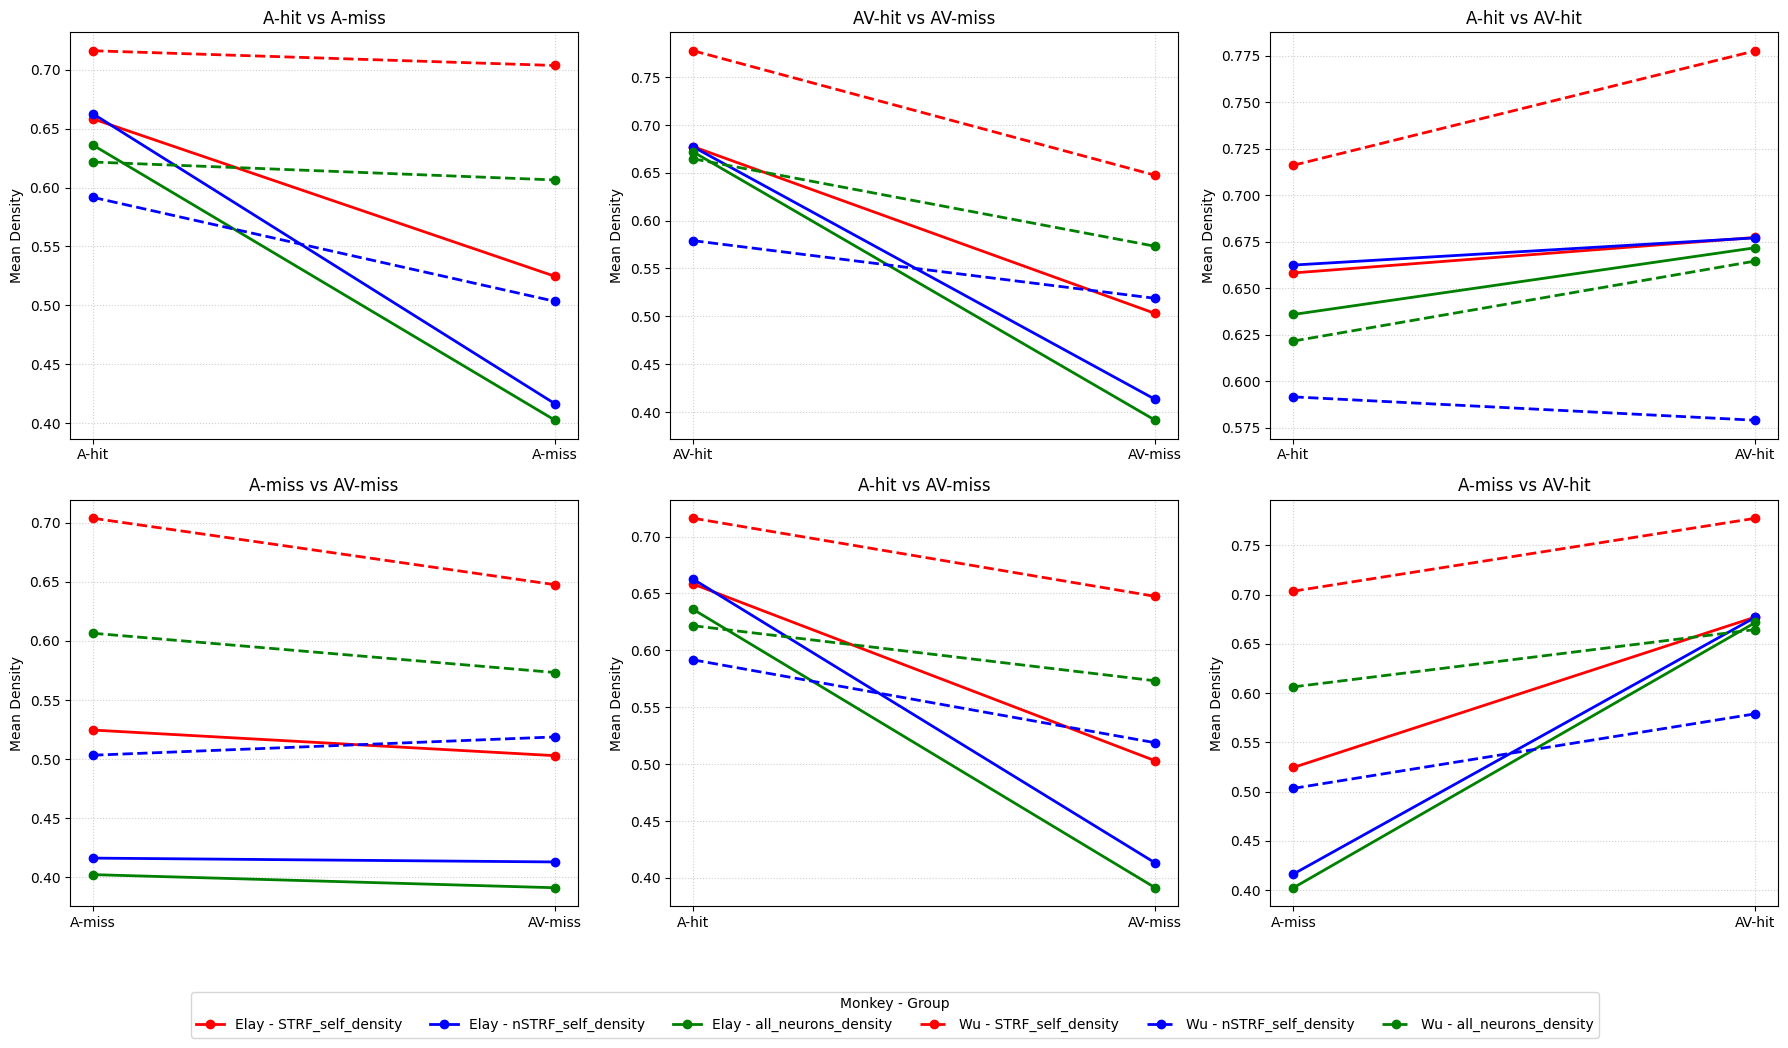

In [32]:
pairs = [
    ('A-hit', 'A-miss'),
    ('AV-hit', 'AV-miss'),
    ('A-hit', 'AV-hit'),
    ('A-miss', 'AV-miss'),
    ('A-hit', 'AV-miss'),
    ('A-miss', 'AV-hit')
]

# Create a figure with 2 rows and 3 columns for the 6 pairs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, (c1, c2) in enumerate(pairs):
    ax = axes[idx]
    
    for monkey in monkeys:
        # Filter data for the current monkey
        subset = density_df[density_df['monkey'] == monkey]
        
        for group in all_groups:
            # Calculate mean for condition 1
            mean_c1 = subset[subset['condition'] == c1][group].mean()
            # Calculate mean for condition 2
            mean_c2 = subset[subset['condition'] == c2][group].mean()
            
            # Plot the slope line
            ax.plot([0, 1], [mean_c1, mean_c2], 
                    marker='o', 
                    color=group_colors[group], 
                    linestyle=monkey_styles[monkey],
                    linewidth=2,
                    label=f"{monkey} - {group}" if idx == 0 else "") # Add label only for the first subplot for legend clarity

    # Set titles and labels
    ax.set_title(f"{c1} vs {c2}")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([c1, c2])
    ax.set_ylabel("Mean Density")
    ax.grid(True, linestyle=':', alpha=0.6)

# Create a custom legend to handle both color (group) and linestyle (monkey)
legend_elements = []
for monkey in monkeys:
    for group in all_groups:
        label = f"{monkey} - {group}"
        color = group_colors[group]
        style = monkey_styles[monkey]
        legend_elements.append(plt.Line2D([0], [0], color=color, linestyle=style, marker='o', label=label, linewidth=2))

fig.legend(handles=legend_elements, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.05), title="Monkey - Group")

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Adjust rect to make space for the legend at the bottom
plt.show()

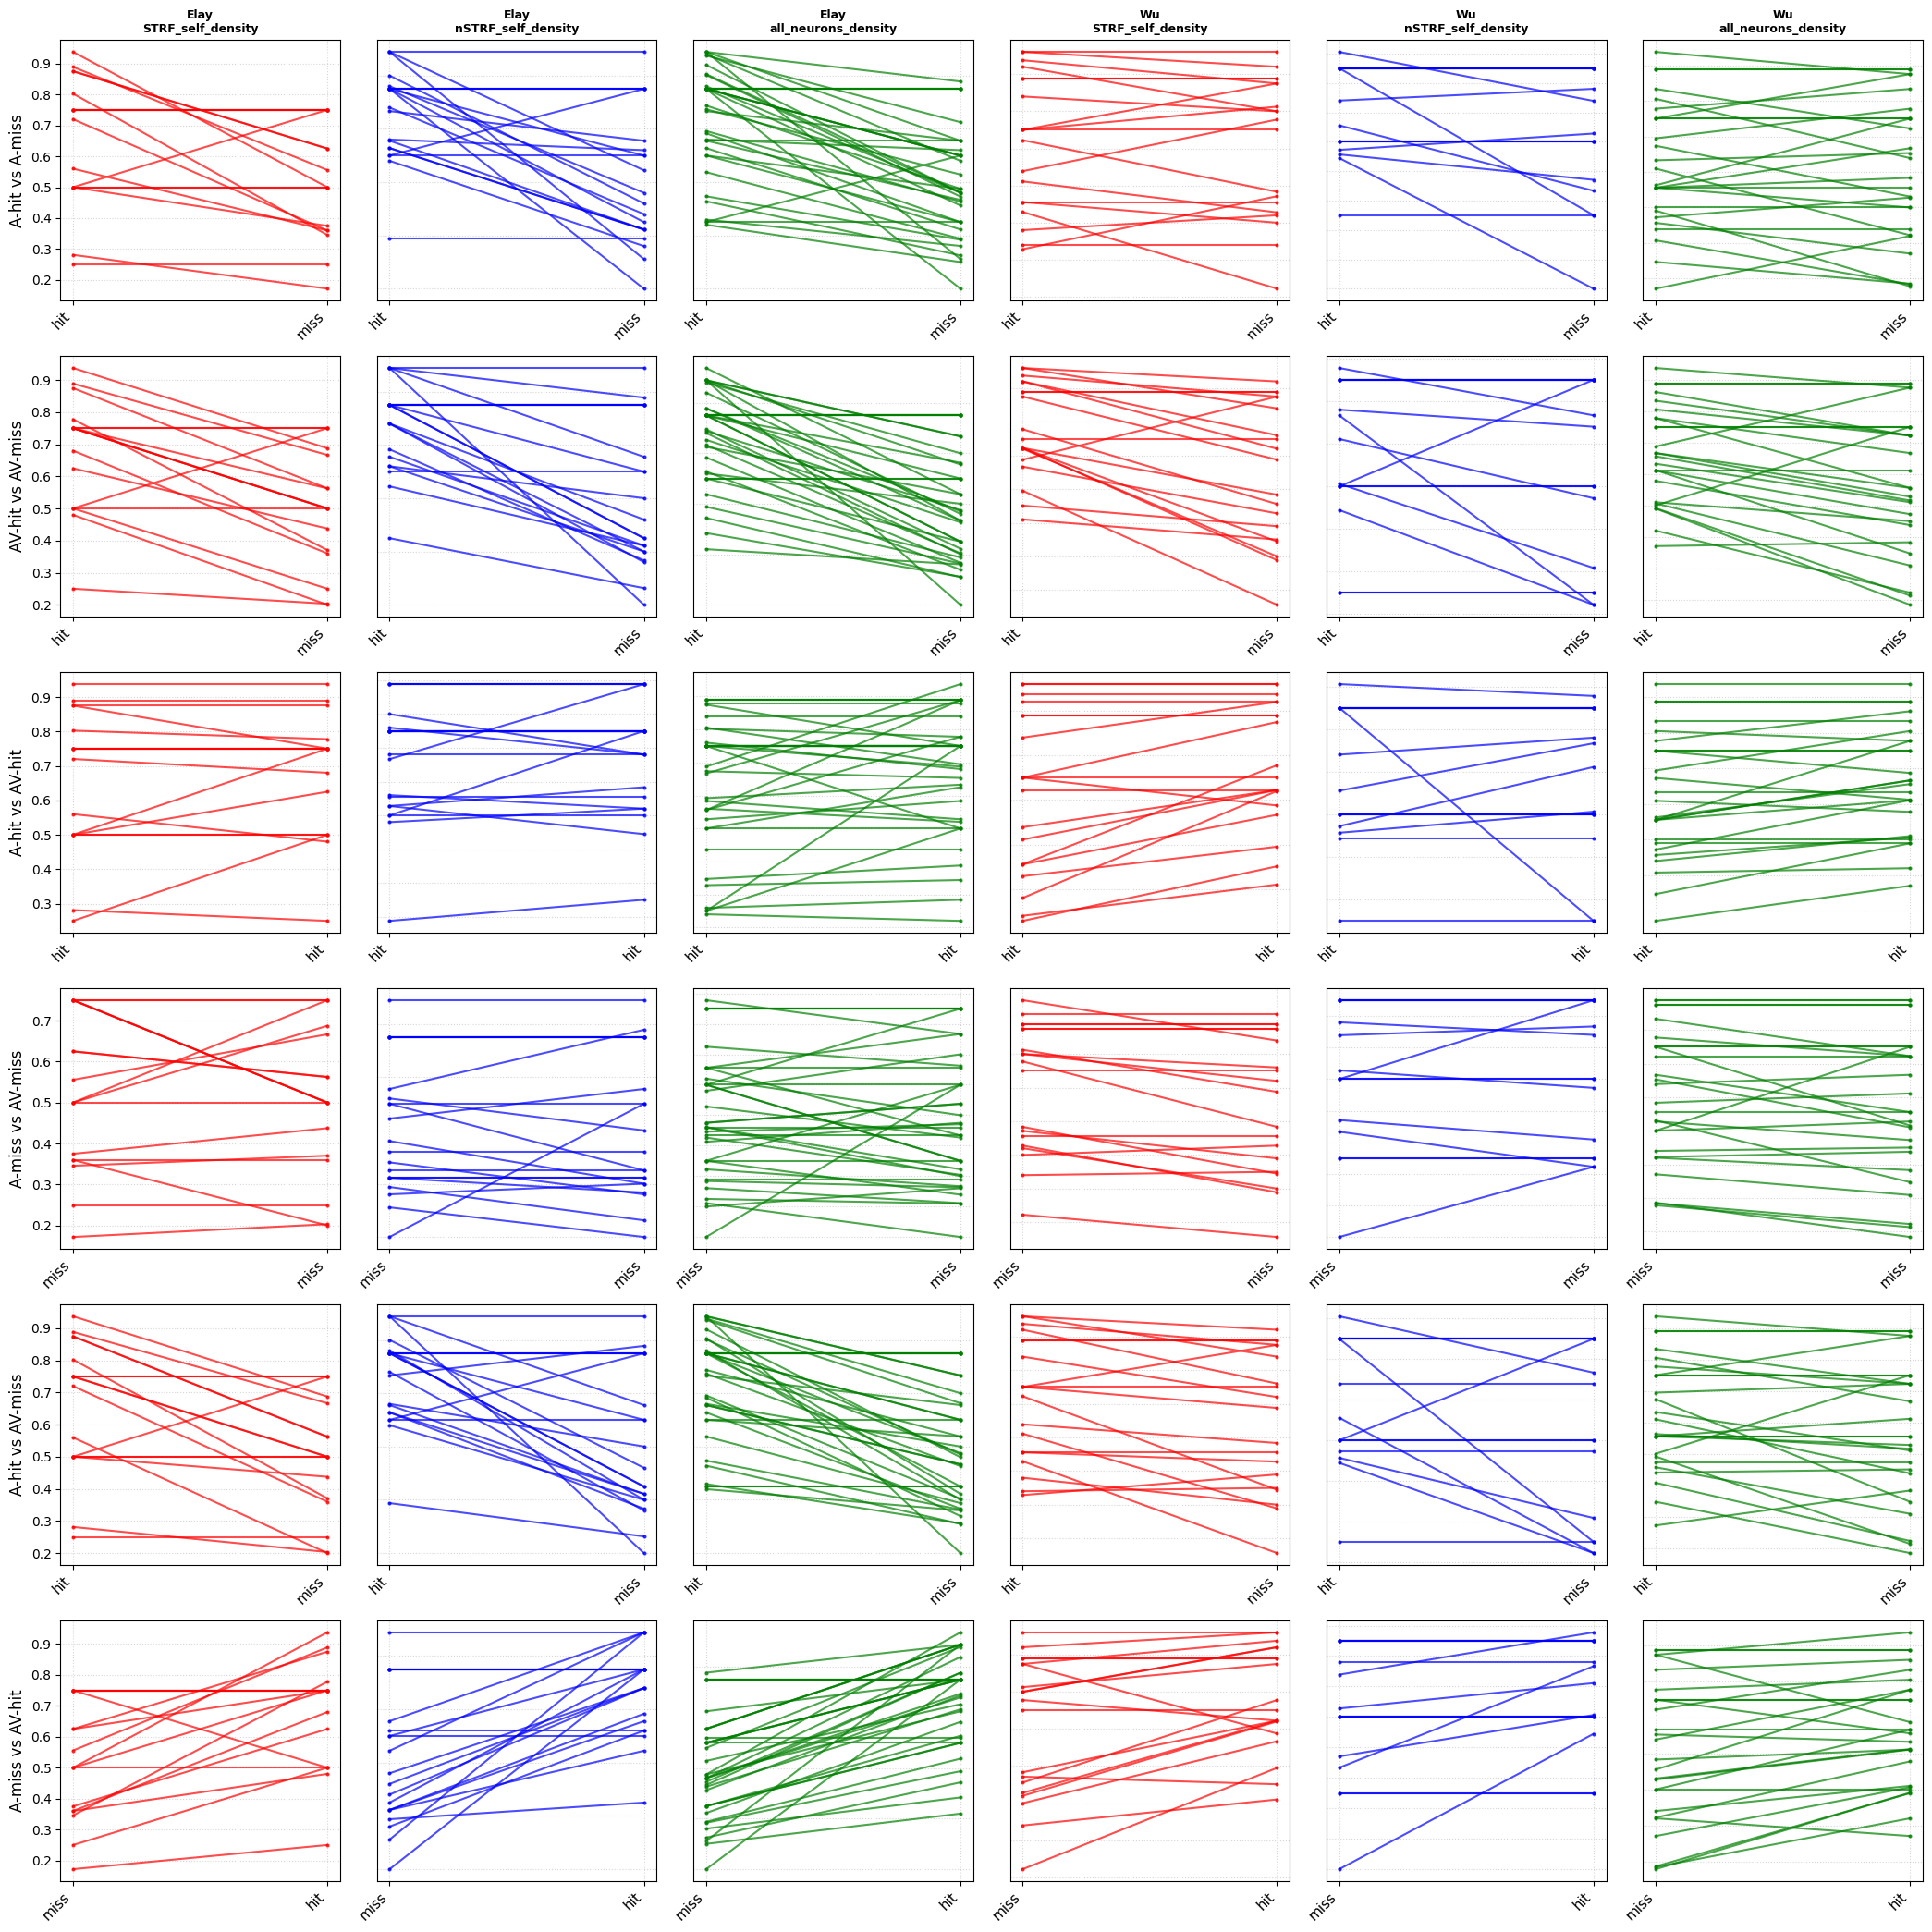

In [33]:
pairs = [
    ('A-hit', 'A-miss'),
    ('AV-hit', 'AV-miss'),
    ('A-hit', 'AV-hit'),
    ('A-miss', 'AV-miss'),
    ('A-hit', 'AV-miss'),
    ('A-miss', 'AV-hit')
]
# Create a figure with 6 rows (Pairs) and 6 columns (2 Monkeys * 3 Groups)
# figsize adjusted to accommodate 6 columns
fig, axes = plt.subplots(6, 6, figsize=(21, 21), sharey=False)

# Iterate through condition pairs (Rows)
for row_idx, (c1, c2) in enumerate(pairs):
    
    # Iterate through Monkeys and Groups to fill the 6 columns
    for col_idx, monkey in enumerate(monkeys):
        for grp_idx, group in enumerate(all_groups):
            
            # Calculate the column index in the 6-column grid
            # Columns 0-2: Elay (STRF, nSTRF, All)
            # Columns 3-5: Wu (STRF, nSTRF, All)
            actual_col_idx = col_idx * 3 + grp_idx
            
            ax = axes[row_idx, actual_col_idx]
            
            # Filter data for the current monkey
            subset = density_df[density_df['monkey'] == monkey]
            
            # Get data for condition 1
            df_c1 = subset[subset['condition'] == c1][['date_id', group]].rename(columns={group: 'val_c1'})
            # Get data for condition 2
            df_c2 = subset[subset['condition'] == c2][['date_id', group]].rename(columns={group: 'val_c2'})
            
            # Merge on date_id to ensure we only plot pairs that exist in both conditions
            df_merged = pd.merge(df_c1, df_c2, on='date_id', how='inner')
            
            # Plot each date_id as a separate line
            # Since we are plotting individual groups, we use the specific group color
            for _, row in df_merged.iterrows():
                ax.plot([0, 1], [row['val_c1'], row['val_c2']], 
                        marker='o', 
                        markersize=2,
                        color=group_colors[group], 
                        linewidth=1.5,
                        alpha=0.7) 

            # Set titles only for the top row
            if row_idx == 0:
                ax.set_title(f"{monkey}\n{group}", fontsize=9, fontweight='bold')
            
            # Set y-labels only for the first column of each monkey block (optional, or just left-most)
            # Here we set it for the very first column to keep it clean, or every 3rd column
            if actual_col_idx == 0:
                ax.set_ylabel(f"{c1} vs {c2}", fontsize=12)
            
            # Hide y-ticks for other columns to reduce clutter if desired
            if actual_col_idx != 0:
                ax.tick_params(left=False, labelleft=False)

            # Set x-ticks
            ax.set_xticks([0, 1])
            ax.set_xticklabels([c1.split('-')[1], c2.split('-')[1]], rotation=45, ha='right', fontsize=11)
            
            ax.grid(True, linestyle=':', alpha=0.5)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# 7. Wilcoxon Signed Test

### two-sided

/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approxima

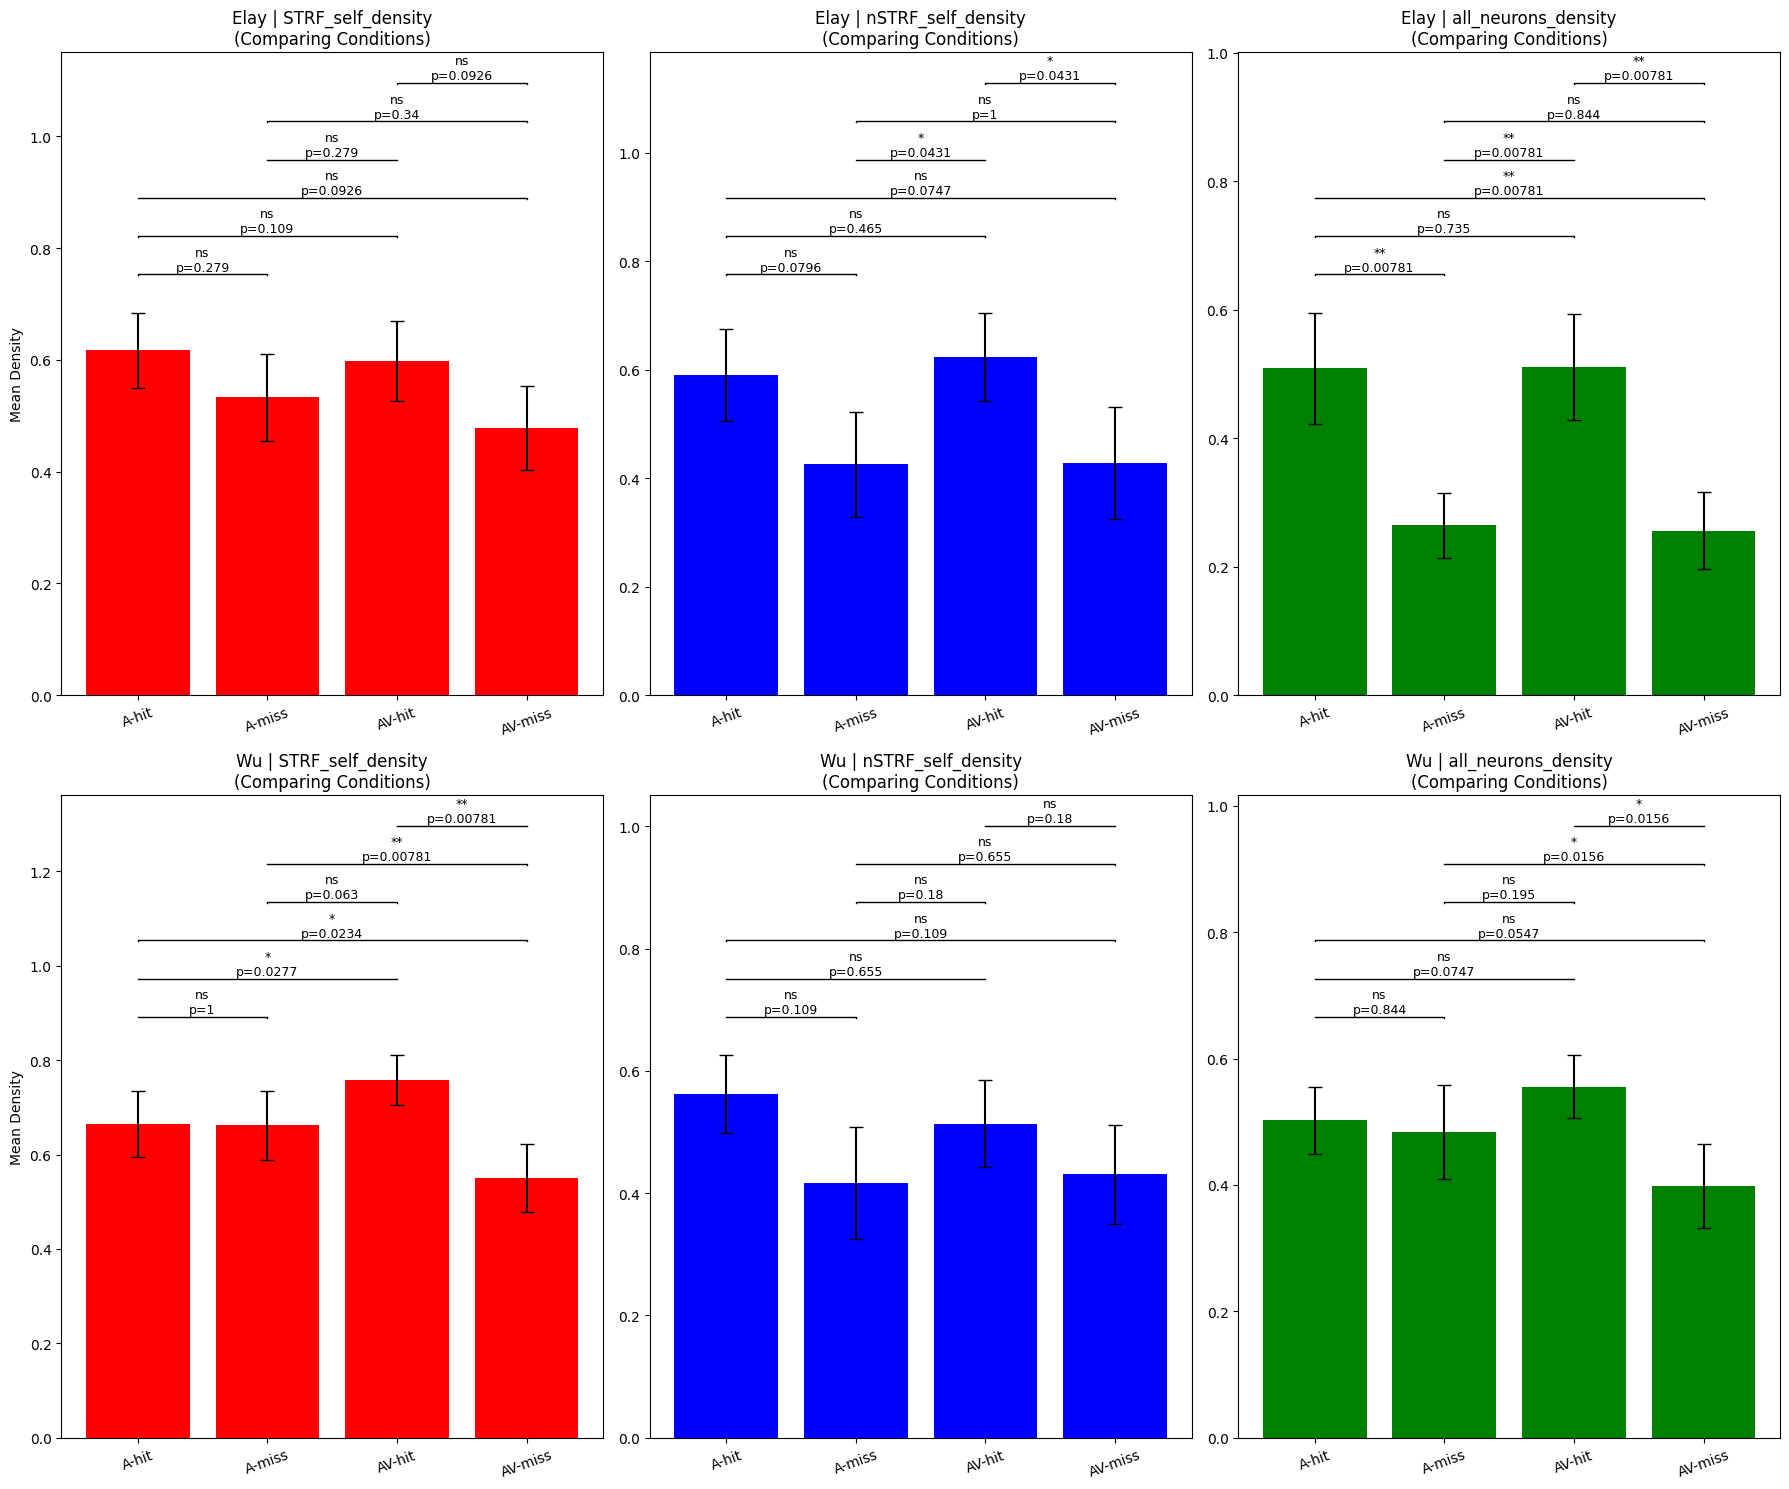

/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approxima

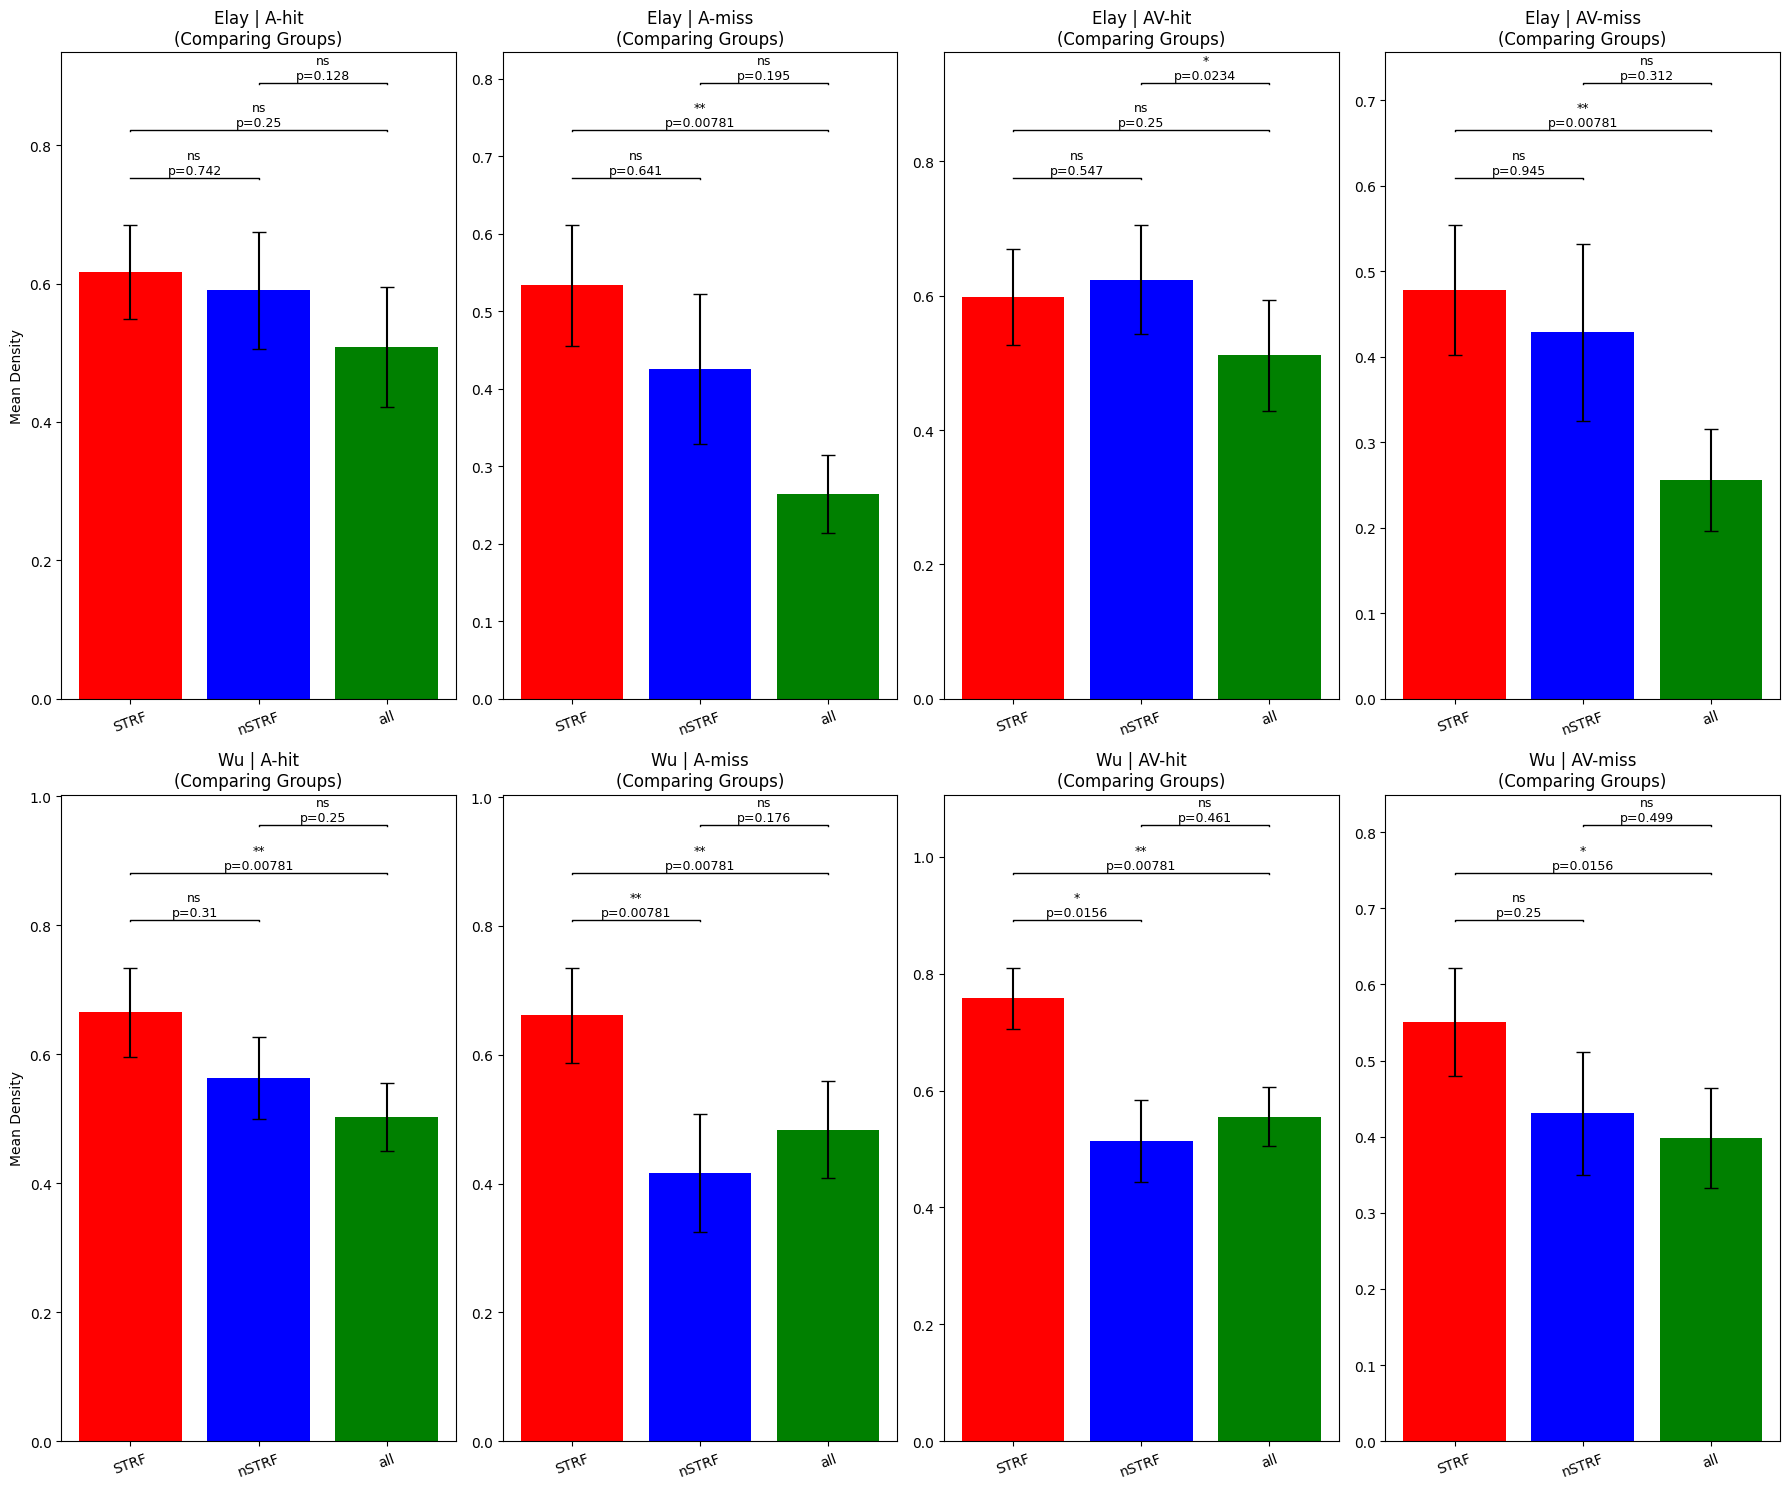

In [35]:


# Predefined color rule
# group_colors = {'STRF_self_density': 'red', 'nSTRF_self_density': 'blue', 'all_neurons_density': 'green'}

# Ensure data is clean
density_df_clean = density_df.dropna(subset=all_groups + ['monkey', 'condition'])

results_paired_wilcoxon_2sided_byconditions = {}

fig1, axes1 = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes1[i, j]
        means = []
        sems = []
        
        cond_data = {}
        for cond in all_cond:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            cond_data[cond] = vals
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_cond))
        bar_color = group_colors.get(group, 'skyblue')
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}\n(Comparing Conditions)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
        
        for k, (a_idx, b_idx) in enumerate(cond_pairs):
            cond_a = all_cond[a_idx]
            cond_b = all_cond[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_a)][['date_id', group]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_b)][['date_id', group]]
            
            # Rename columns to ensure unique suffixes after merge
            df_a = df_a.rename(columns={group: f'{group}_a'})
            df_b = df_b.rename(columns={group: f'{group}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    #actual test here
                    tstat, pval = wilcoxon(merged[f'{group}_a'], merged[f'{group}_b'])
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{group}|{cond_a}_vs_{cond_b}"
            results_paired_wilcoxon_2sided_byconditions[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

results_paired_wilcoxon_2sided_bygroups = {}

fig2, axes2 = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes2[i, j]
        means = []
        sems = []
        
        group_data = {}
        for group in all_groups:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            group_data[group] = vals
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_groups))
        # Apply predefined colors for each group bar
        bar_colors = [group_colors.get(g, 'gray') for g in all_groups]
        
        ax.bar(x, means, yerr=sems, capsize=5, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('_self_density', '').replace('_neurons_density', '') for g in all_groups], rotation=20)
        ax.set_title(f"{monkey} | {cond}\n(Comparing Groups)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)
        
        group_indices = list(range(len(all_groups)))
        group_pairs = [(0, 1), (0, 2), (1, 2)]
        
        for k, (a_idx, b_idx) in enumerate(group_pairs):
            grp_a = all_groups[a_idx]
            grp_b = all_groups[b_idx]
            
            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_a]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_b]]
            
            # Rename columns to ensure unique suffixes after merge
            df_a = df_a.rename(columns={grp_a: f'{grp_a}_a'})
            df_b = df_b.rename(columns={grp_b: f'{grp_b}_b'})
            
            merged = pd.merge(df_a, df_b, on='date_id', how='inner')
            
            if len(merged) < 2:
                pval = np.nan
                stars = 'n/a'
            else:
                try:
                    tstat, pval = wilcoxon(merged[f'{grp_a}_a'], merged[f'{grp_b}_b'])
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    stars = 'err'
                
            key = f"{monkey}|{cond}|{grp_a}_vs_{grp_b}"
            results_paired_wilcoxon_2sided_bygroups[key] = {'t': tstat if 'tstat' in locals() else np.nan, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### one-sided

/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approxima

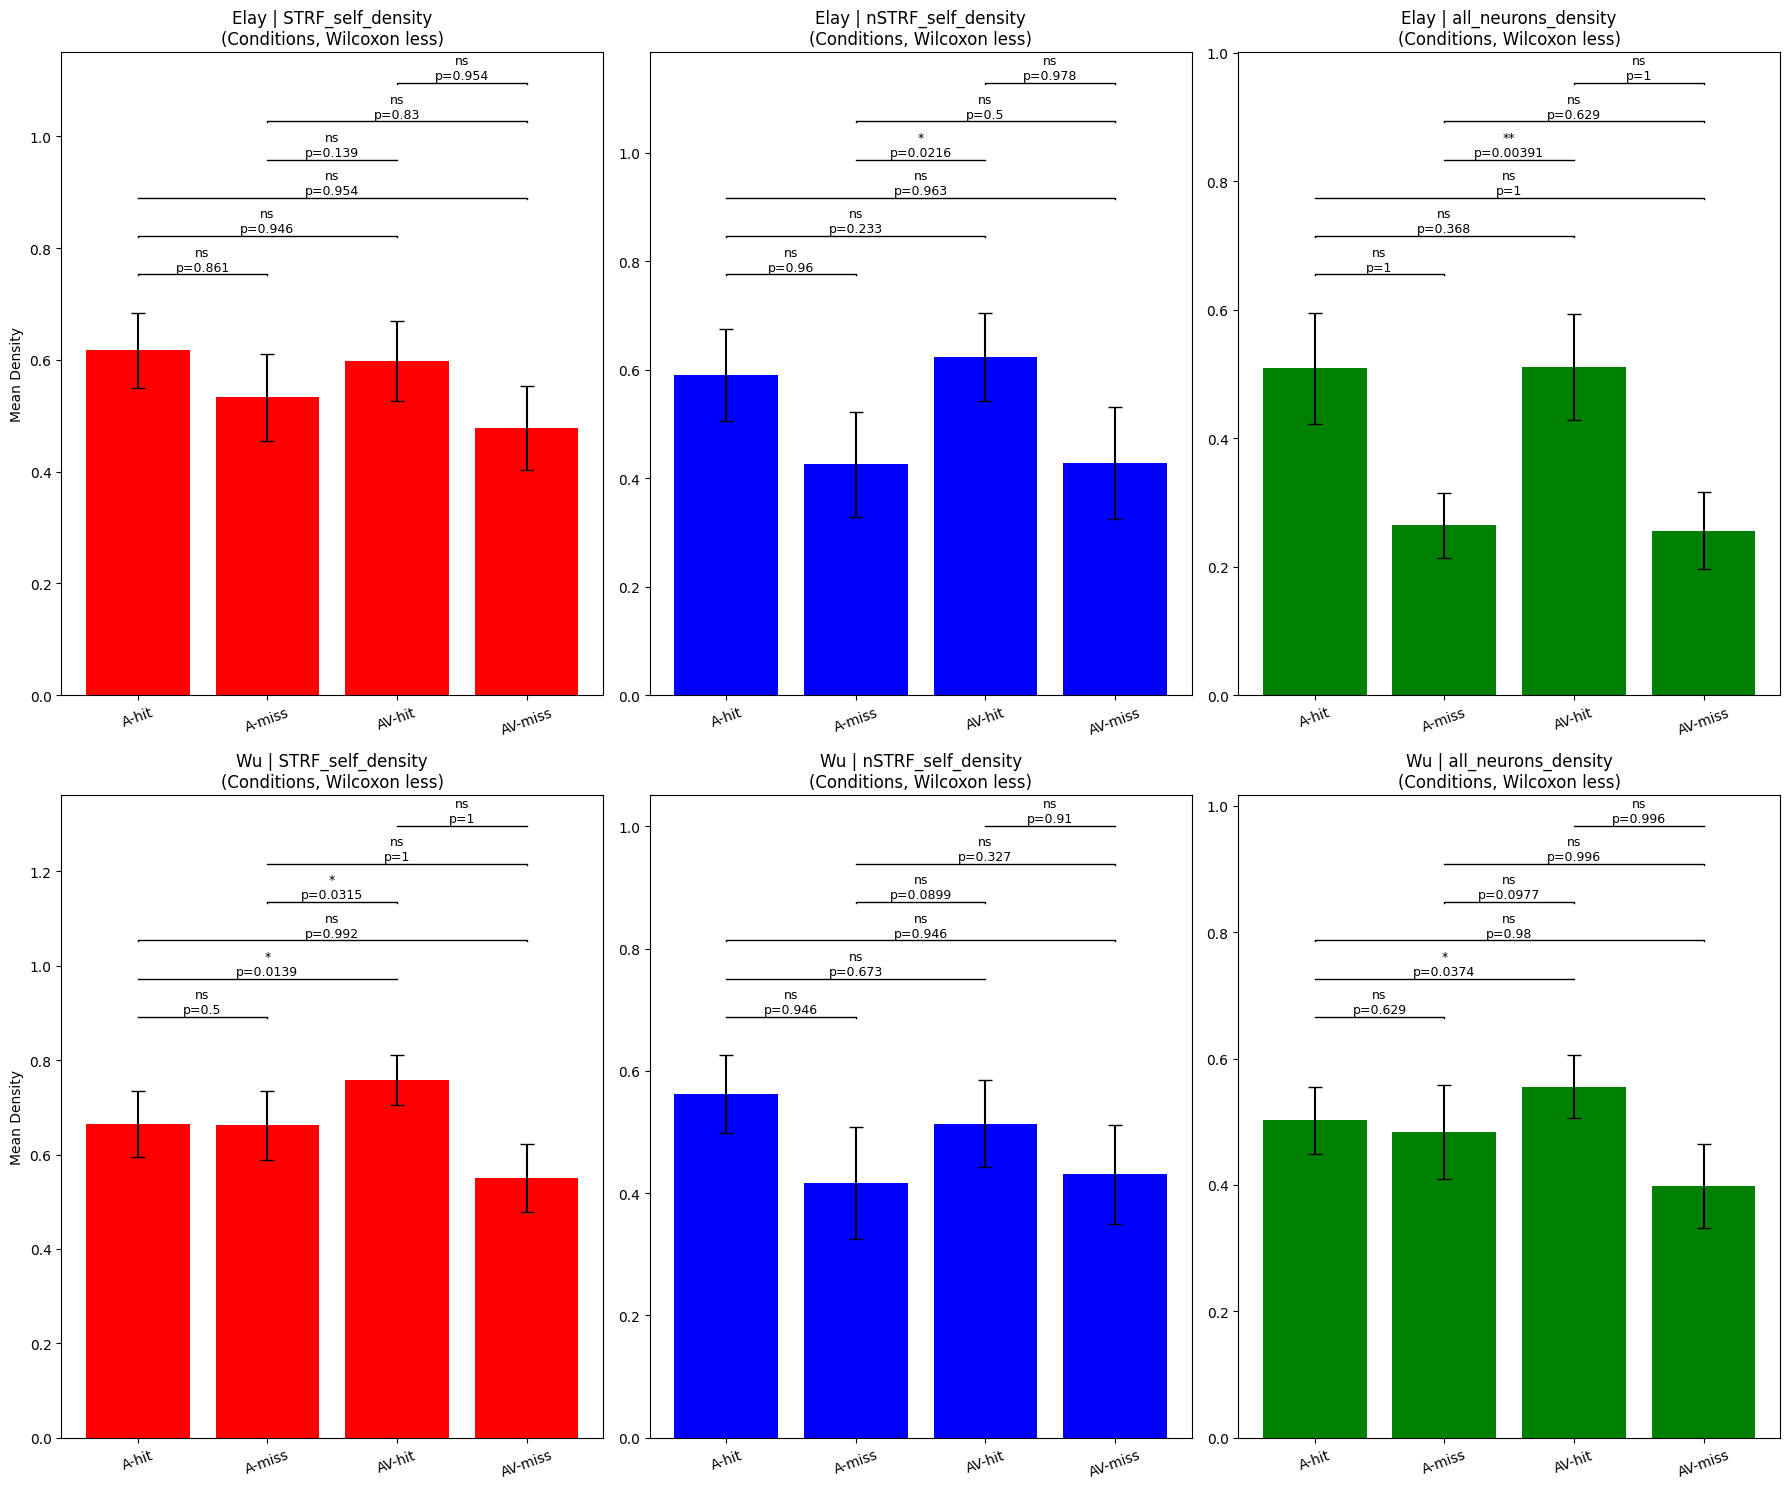

/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approxima

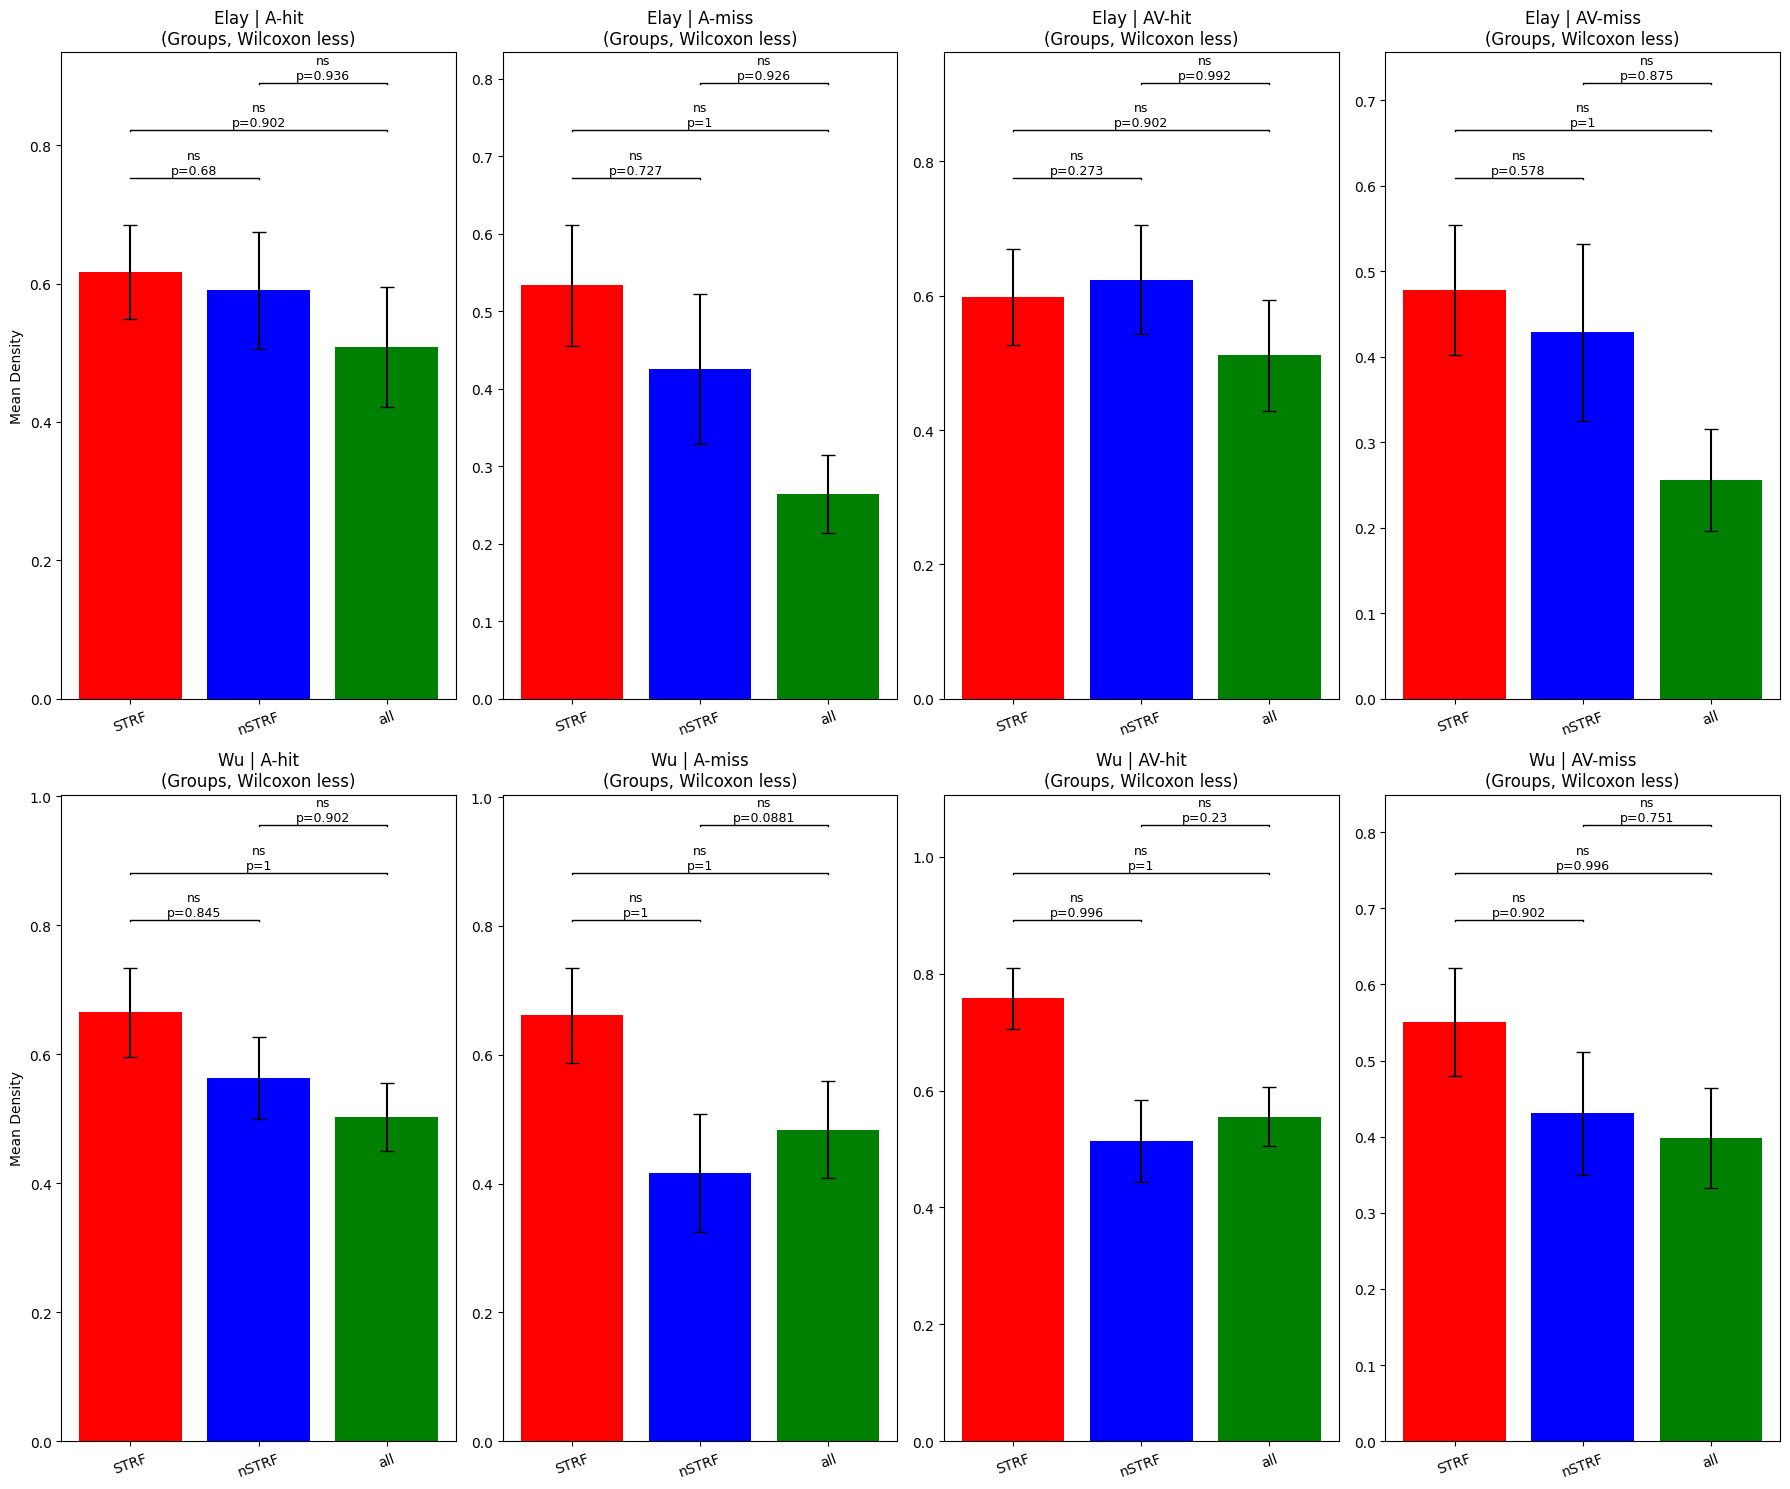

In [36]:
results_paired_wilcoxon_less_byconditions = {}

fig_cond_wilcoxon_less, axes_cond_wilcoxon_less = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes_cond_wilcoxon_less[i, j]
        means = []
        sems = []

        for cond in all_cond:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_cond))
        bar_color = group_colors.get(group, 'skyblue')

        ax.bar(x, means, yerr=sems, capsize=5, color=bar_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}\n(Conditions, Wilcoxon less)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

        for k, (a_idx, b_idx) in enumerate(cond_pairs):
            cond_a = all_cond[a_idx]
            cond_b = all_cond[b_idx]

            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_a)][['date_id', group]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_b)][['date_id', group]]

            df_a = df_a.rename(columns={group: f'{group}_a'})
            df_b = df_b.rename(columns={group: f'{group}_b'})

            merged = pd.merge(df_a, df_b, on='date_id', how='inner')

            if len(merged) < 5:
                pval = np.nan
                wstat = np.nan
                stars = 'n/a'
            else:
                try:
                    wstat, pval = wilcoxon(merged[f'{group}_a'], merged[f'{group}_b'], alternative='less')
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    wstat = np.nan
                    stars = 'err'

            key = f"{monkey}|{group}|{cond_a}_vs_{cond_b}"
            results_paired_wilcoxon_less_byconditions[key] = {'W': wstat, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

results_paired_wilcoxon_less_bygroups = {}

fig_grp_wilcoxon_less, axes_grp_wilcoxon_less = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes_grp_wilcoxon_less[i, j]
        means = []
        sems = []

        for group in all_groups:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_groups))
        bar_colors = [group_colors.get(g, 'gray') for g in all_groups]

        ax.bar(x, means, yerr=sems, capsize=5, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('_self_density', '').replace('_neurons_density', '') for g in all_groups], rotation=20)
        ax.set_title(f"{monkey} | {cond}\n(Groups, Wilcoxon less)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        group_pairs = [(0, 1), (0, 2), (1, 2)]

        for k, (a_idx, b_idx) in enumerate(group_pairs):
            grp_a = all_groups[a_idx]
            grp_b = all_groups[b_idx]

            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_a]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_b]]

            df_a = df_a.rename(columns={grp_a: f'{grp_a}_a'})
            df_b = df_b.rename(columns={grp_b: f'{grp_b}_b'})

            merged = pd.merge(df_a, df_b, on='date_id', how='inner')

            if len(merged) < 5:
                pval = np.nan
                wstat = np.nan
                stars = 'n/a'
            else:
                try:
                    wstat, pval = wilcoxon(merged[f'{grp_a}_a'], merged[f'{grp_b}_b'], alternative='less')  # FIXED
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    wstat = np.nan
                    stars = 'err'

            key = f"{monkey}|{cond}|{grp_a}_vs_{grp_b}"
            results_paired_wilcoxon_less_bygroups[key] = {'W': wstat, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approxima

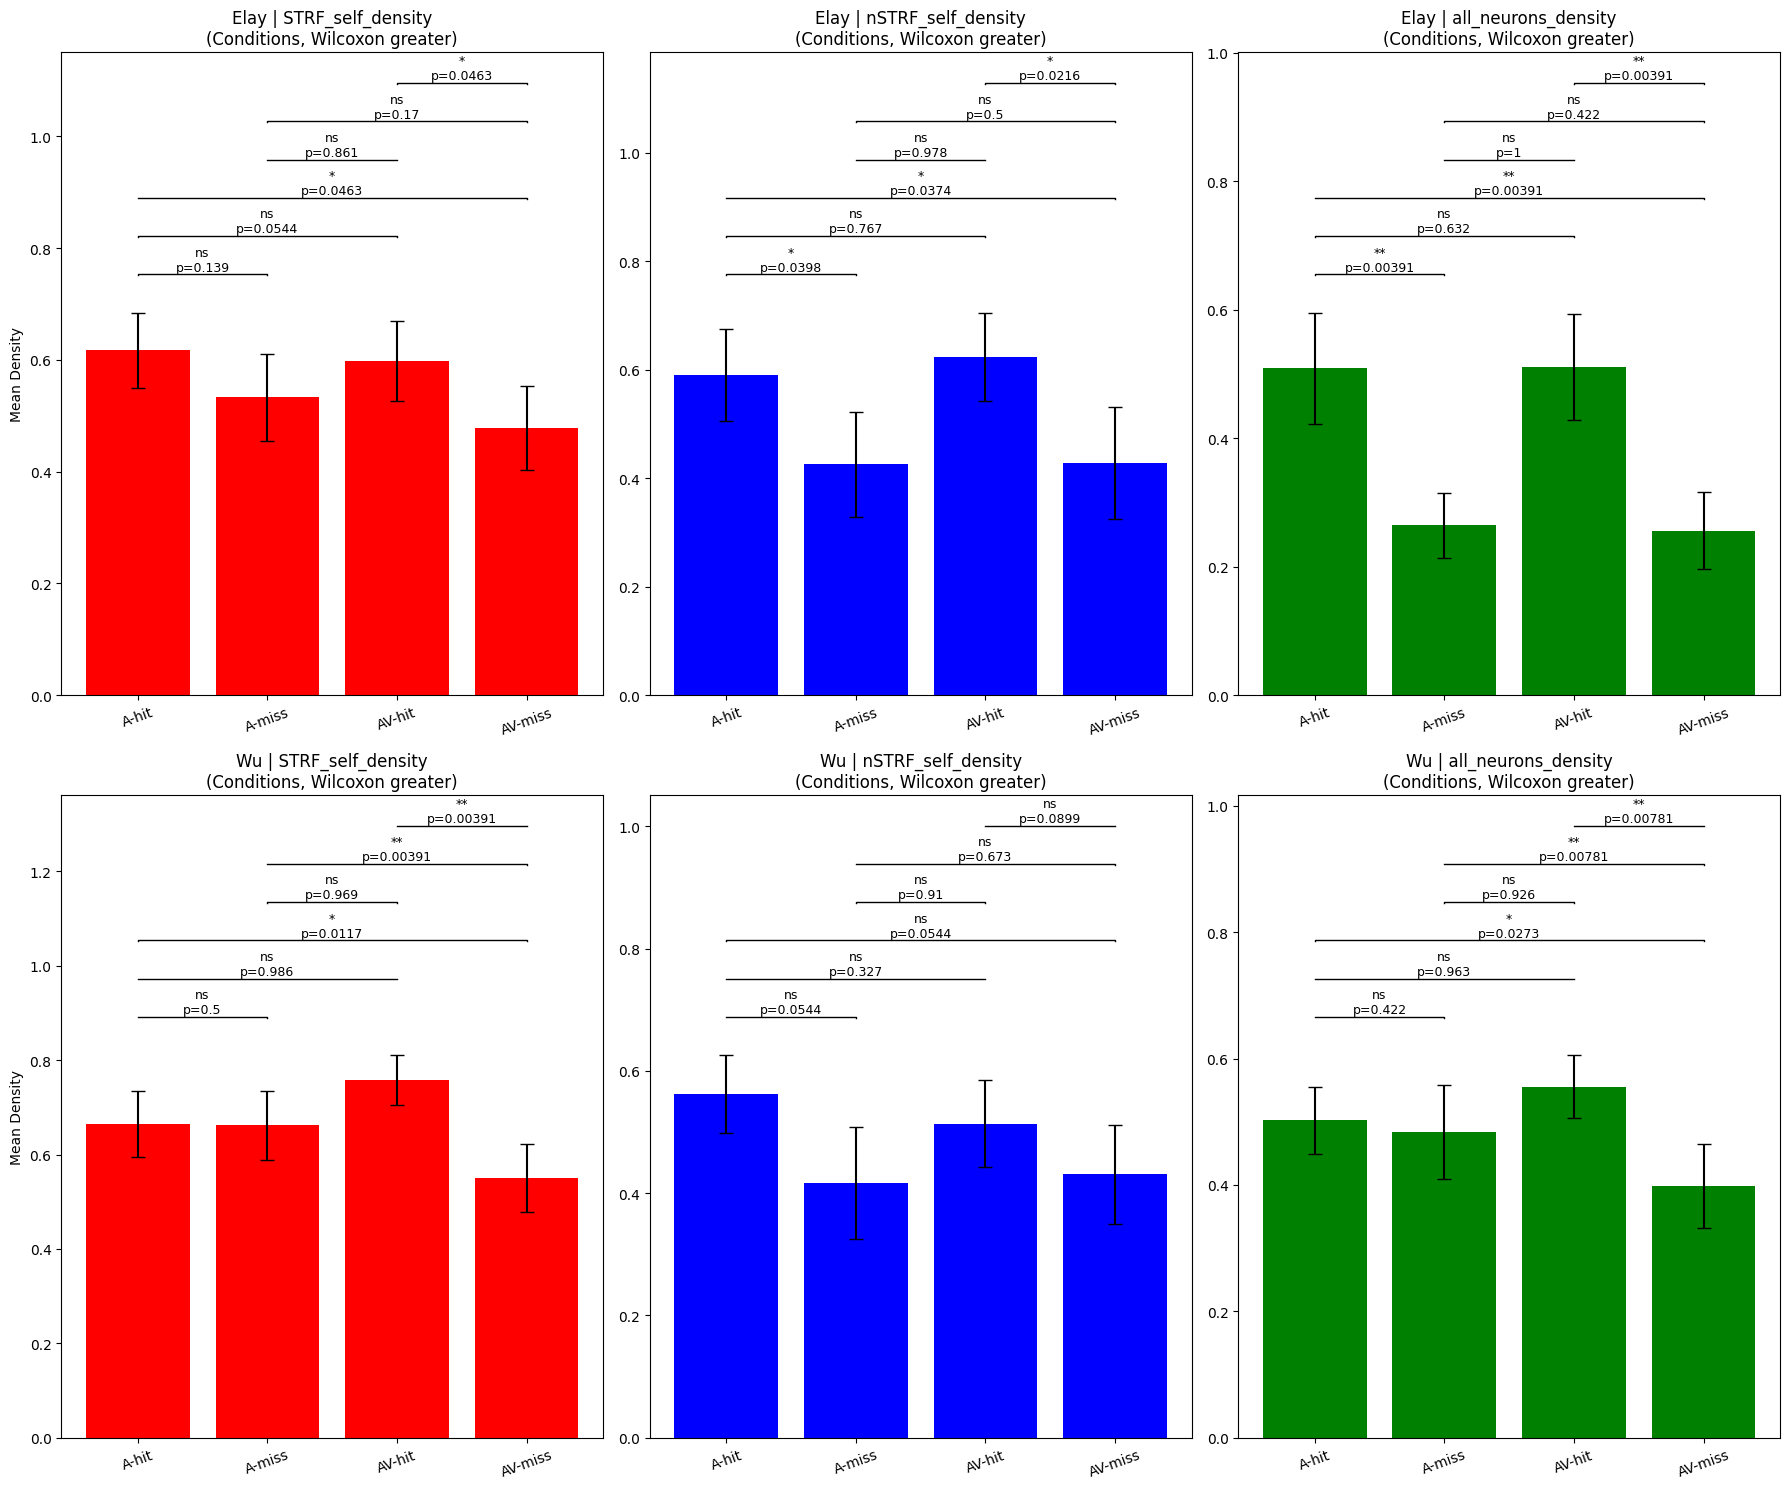

/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/wuruoyu/anaconda3/envs/gesture/lib/python3.9/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approxima

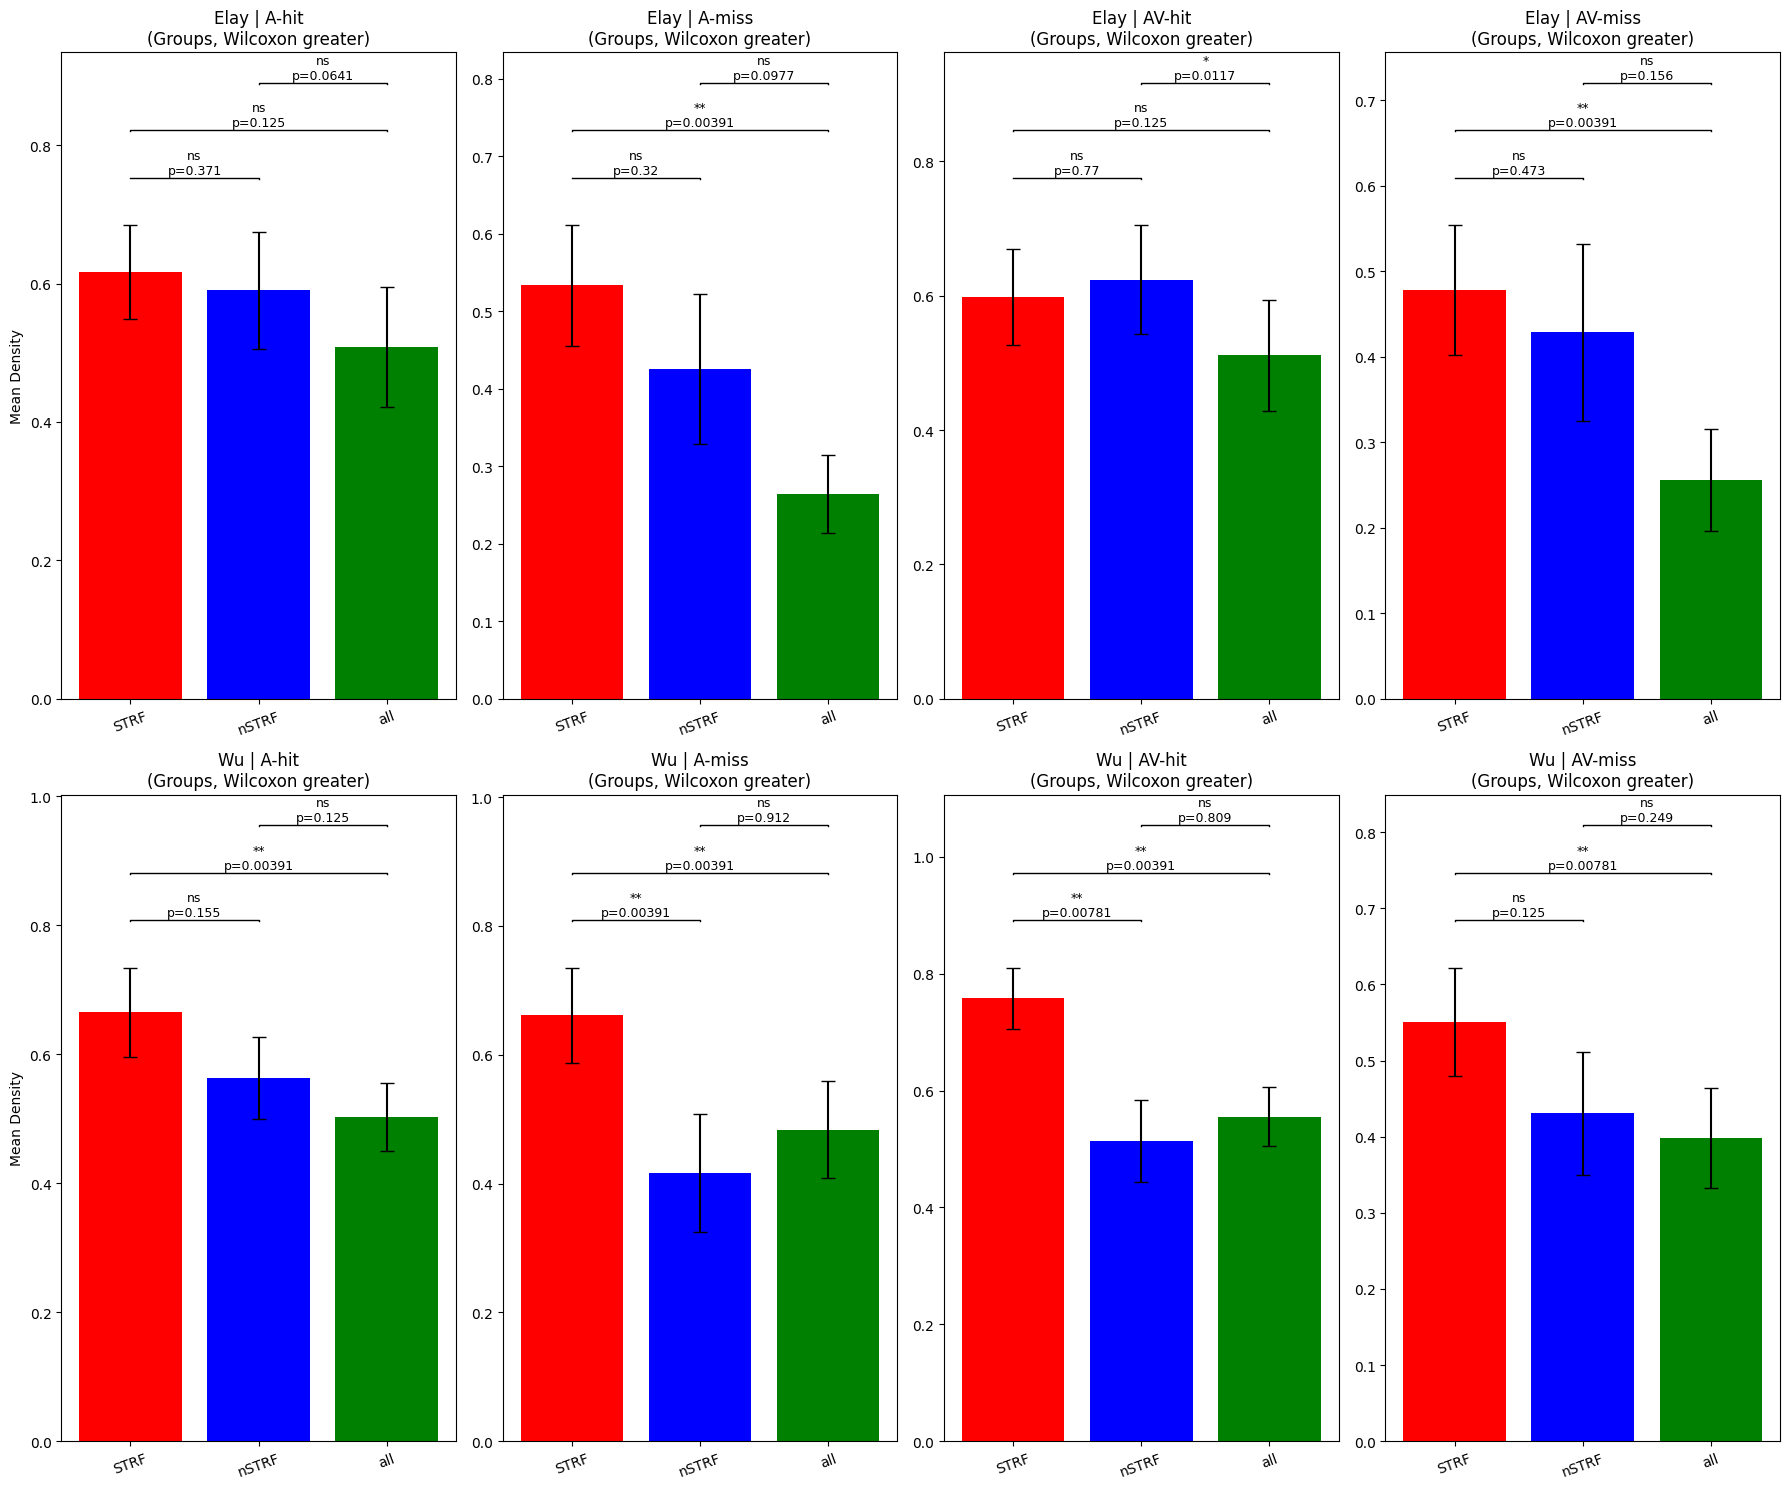

In [37]:
results_paired_wilcoxon_greater_byconditions = {}

fig_cond_wilcoxon_greater, axes_cond_wilcoxon_greater = plt.subplots(len(monkeys), len(all_groups), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, group in enumerate(all_groups):
        ax = axes_cond_wilcoxon_greater[i, j]
        means = []
        sems = []

        for cond in all_cond:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_cond))
        bar_color = group_colors.get(group, 'skyblue')

        ax.bar(x, means, yerr=sems, capsize=5, color=bar_color)
        ax.set_xticks(x)
        ax.set_xticklabels(all_cond, rotation=20)
        ax.set_title(f"{monkey} | {group}\n(Conditions, Wilcoxon greater)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        cond_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

        for k, (a_idx, b_idx) in enumerate(cond_pairs):
            cond_a = all_cond[a_idx]
            cond_b = all_cond[b_idx]

            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_a)][['date_id', group]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond_b)][['date_id', group]]

            df_a = df_a.rename(columns={group: f'{group}_a'})
            df_b = df_b.rename(columns={group: f'{group}_b'})

            merged = pd.merge(df_a, df_b, on='date_id', how='inner')

            if len(merged) < 5:
                pval = np.nan
                wstat = np.nan
                stars = 'n/a'
            else:
                try:
                    wstat, pval = wilcoxon(merged[f'{group}_a'], merged[f'{group}_b'], alternative='greater')
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    wstat = np.nan
                    stars = 'err'

            key = f"{monkey}|{group}|{cond_a}_vs_{cond_b}"
            results_paired_wilcoxon_greater_byconditions[key] = {'W': wstat, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

results_paired_wilcoxon_greater_bygroups = {}

fig_grp_wilcoxon_greater, axes_grp_wilcoxon_greater = plt.subplots(len(monkeys), len(all_cond), figsize=(18, 15), sharey=False, squeeze=False)

for i, monkey in enumerate(monkeys):
    for j, cond in enumerate(all_cond):
        ax = axes_grp_wilcoxon_greater[i, j]
        means = []
        sems = []

        for group in all_groups:
            subset = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)]
            vals = subset[group].dropna()
            means.append(vals.mean())
            sems.append(vals.sem())

        x = np.arange(len(all_groups))
        bar_colors = [group_colors.get(g, 'gray') for g in all_groups]

        ax.bar(x, means, yerr=sems, capsize=5, color=bar_colors)
        ax.set_xticks(x)
        ax.set_xticklabels([g.replace('_self_density', '').replace('_neurons_density', '') for g in all_groups], rotation=20)
        ax.set_title(f"{monkey} | {cond}\n(Groups, Wilcoxon greater)")
        if j == 0:
            ax.set_ylabel('Mean Density')

        y_base = np.nanmax(np.array(means) + np.array(sems))
        if np.isnan(y_base): y_base = 0.0
        y_step = max(0.1 * y_base, 0.05)

        group_pairs = [(0, 1), (0, 2), (1, 2)]

        for k, (a_idx, b_idx) in enumerate(group_pairs):
            grp_a = all_groups[a_idx]
            grp_b = all_groups[b_idx]

            df_a = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_a]]
            df_b = density_df_clean[(density_df_clean['monkey'] == monkey) & (density_df_clean['condition'] == cond)][['date_id', grp_b]]

            df_a = df_a.rename(columns={grp_a: f'{grp_a}_a'})
            df_b = df_b.rename(columns={grp_b: f'{grp_b}_b'})

            merged = pd.merge(df_a, df_b, on='date_id', how='inner')

            if len(merged) < 5:
                pval = np.nan
                wstat = np.nan
                stars = 'n/a'
            else:
                try:
                    wstat, pval = wilcoxon(merged[f'{grp_a}_a'], merged[f'{grp_b}_b'], alternative='greater')  # FIXED
                    if pval < 0.001: stars = '***'
                    elif pval < 0.01: stars = '**'
                    elif pval < 0.05: stars = '*'
                    else: stars = 'ns'
                except Exception:
                    pval = np.nan
                    wstat = np.nan
                    stars = 'err'

            key = f"{monkey}|{cond}|{grp_a}_vs_{grp_b}"
            results_paired_wilcoxon_greater_bygroups[key] = {'W': wstat, 'p': pval, 'n': len(merged)}

            y = y_base + (k + 1) * y_step
            ax.plot([x[a_idx], x[a_idx], x[b_idx], x[b_idx]], [y - 0.015*y_step, y, y, y - 0.02*y_step], color='black', lw=1)
            ax.text((x[a_idx] + x[b_idx]) / 2, y + 0.02*y_step, f'{stars}\np={pval:.3g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()